# Testing 3 Cutoff: Seed 67 Cutoff Generation + Curve-Fitting Evaluation on **All** Curves

Run this notebook from anywhere. It will try to find your folder automatically, with the expected path:

```text
/Users/andrewwang/Downloads/LIGHT/testing 3 cutoff
```

What it does:

1. Finds every matching `curve_*.dat` and `params_*.dat` pair in the year subfolders.
2. Uses `MicrolensingDataset.__getitem__` from `ulab_data_edited.py` with seed `67` to generate deterministic pseudo-random cutoff files for **all valid curves**, not just 50.
3. Saves the generated cutoff files in the main `testing 3 cutoff` folder as `curve_<event_id>_cutoff.dat`.
4. Fits the same differentiable Paczyński microlensing curve model to each generated cutoff.
5. Outputs the full results table, summary statistics, year breakdowns, outliers, correlations, and best/worst plots.

Important: Cell 1 clears old root-level `curve_*_cutoff.dat` files before generating new seed-67 cutoffs, so stale 50-event cutoffs do not get mixed with the all-curve run.


Current working directory: /Users/andrewwang/Downloads/LIGHT/testing 3 cutoff
BASE_DIR: /Users/andrewwang/Downloads/LIGHT/testing 3 cutoff
Seed: 67
MAX_EVENTS: None
ulab_data_edited.py exists: True
ulab_data_edited(1).py exists: False
Imported MicrolensingDataset from: /Users/andrewwang/Downloads/LIGHT/testing 3 cutoff/ulab_data_edited.py
Cleared old root-level cutoff files: 0
Found full curve files: 673
Found params files: 673
Matched curve-params pairs before optional limit: 673
Matched curve-params pairs used: 673
Valid events after MicrolensingDataset internal filtering: 673
Generated cutoff files: 673
Saved: all_seed67_cutoff_generation_summary.csv


,event_id,year,curve_file,params_file,cutoff_file,full_points,dataset_trimmed_points,cutoff_points,cutoff_fraction_of_trimmed,cutoff_end_hjd,first_time_added_back,ibl_added_back
0,2011_0133,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,1854,228,125,0.548246,2455655.75,2455459.50,19.146500
1,2011_0135,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,3596,102,101,0.990196,2455710.75,2455702.75,18.735001
2,2011_0153,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,2131,1283,1274,0.992985,2455752.50,2455436.75,13.713000
3,2011_0164,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,188,60,59,0.983333,2455641.00,2455423.50,19.430500
4,2011_0199,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,799,166,98,0.590361,2455656.00,2455481.50,19.622000


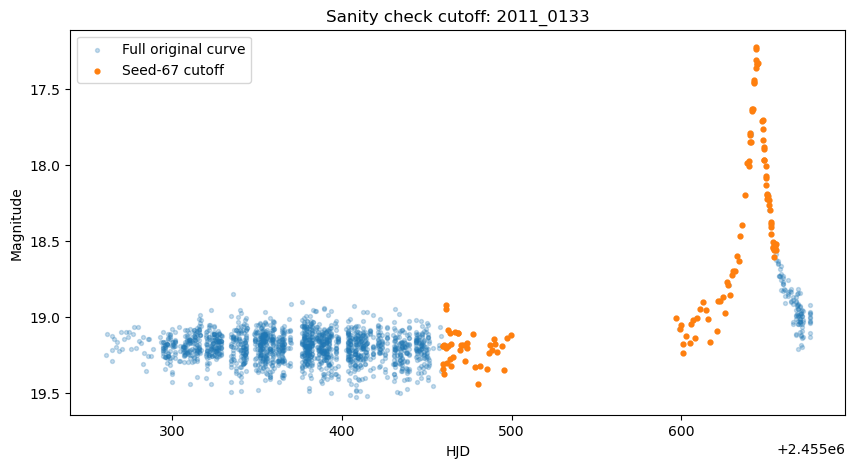

In [1]:

# ============================
# CELL 1: SETUP + CREATE SEED-67 CUTOFF FILES FOR ALL VALID CURVES
# ============================

from pathlib import Path
import os
import re
import random
import glob
import shutil
import importlib.util

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------

SEED = 67
MAX_EVENTS = None                 # None = use ALL valid curves after MicrolensingDataset filtering
OVERWRITE_CUTOFFS = True
CLEAR_OLD_ROOT_CUTOFFS = True     # Delete old root-level curve_*_cutoff.dat files before regenerating all cutoffs
EXPECTED_EVENTS = None            # None = no warning. Set to a number only if you expect an exact count.

# Try to find the actual testing folder automatically.
# Your Finder screenshot showed this path:
HARDCODED_BASE_DIR = Path("/Users/andrewwang/Downloads/LIGHT/testing 3 cutoff")

candidate_dirs = [
    HARDCODED_BASE_DIR,
    Path.cwd(),
    Path.cwd() / "testing 3 cutoff",
    Path.cwd().parent / "testing 3 cutoff",
    Path.home() / "Downloads" / "LIGHT" / "testing 3 cutoff",
]

# Pick the first candidate that contains ulab_data_edited.py and at least one year-subfolder curve file.
BASE_DIR = None
for cand in candidate_dirs:
    cand = cand.expanduser().resolve()
    has_ulab = (cand / "ulab_data_edited.py").exists() or (cand / "ulab_data_edited(1).py").exists()
    has_curves = len(list(cand.glob("*/curve_*.dat"))) > 0
    if cand.exists() and has_ulab and has_curves:
        BASE_DIR = cand
        break

if BASE_DIR is None:
    print("Could not auto-detect BASE_DIR. Candidates checked:")
    for cand in candidate_dirs:
        print("  ", cand.expanduser().resolve())
    raise FileNotFoundError(
        "Could not find the testing folder. Put this notebook inside the folder containing "
        "ulab_data_edited.py and the year subfolders, or edit HARDCODED_BASE_DIR."
    )

os.chdir(BASE_DIR)

print("Current working directory:", Path.cwd())
print("BASE_DIR:", BASE_DIR)
print("Seed:", SEED)
print("MAX_EVENTS:", MAX_EVENTS)
print("ulab_data_edited.py exists:", (BASE_DIR / "ulab_data_edited.py").exists())
print("ulab_data_edited(1).py exists:", (BASE_DIR / "ulab_data_edited(1).py").exists())

# ----------------------------
# IMPORT MicrolensingDataset FROM ulab_data_edited.py
# ----------------------------

ULAB_DATA_CANDIDATES = [
    BASE_DIR / "ulab_data_edited.py",
    BASE_DIR / "ulab_data_edited(1).py",
    BASE_DIR.parent / "ulab_data_edited.py",
    BASE_DIR.parent / "ulab_data_edited(1).py",
]

ulab_path = None
for p in ULAB_DATA_CANDIDATES:
    if p.exists():
        ulab_path = p
        break

if ulab_path is None:
    raise FileNotFoundError(
        "Could not find ulab_data_edited.py. Put ulab_data_edited.py in BASE_DIR "
        "or the parent folder, then rerun this cell."
    )

spec = importlib.util.spec_from_file_location("ulab_data_edited", ulab_path)
ulab_data_edited = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ulab_data_edited)

MicrolensingDataset = ulab_data_edited.MicrolensingDataset
print("Imported MicrolensingDataset from:", ulab_path)

# ----------------------------
# FILE MATCHING HELPERS
# ----------------------------

def extract_event_id(filename):
    name = Path(filename).name
    m = re.search(r"(20\d{2}_\d+)", name)
    return m.group(1) if m else None


def find_full_curve_param_pairs(base_dir):
    """
    Finds ALL full curve/params files recursively under BASE_DIR.
    Excludes generated cutoff files.
    """
    base_dir = Path(base_dir)
    curve_files = sorted([
        p for p in base_dir.glob("**/curve_*.dat")
        if "_cutoff" not in p.name
    ], key=lambda p: str(p))

    param_files = sorted(base_dir.glob("**/params_*.dat"), key=lambda p: str(p))

    params_by_id = {}
    for p in param_files:
        event_id = extract_event_id(p)
        if event_id is not None:
            params_by_id[event_id] = p

    matched_curves = []
    matched_params = []
    matched_ids = []

    for c in curve_files:
        event_id = extract_event_id(c)
        if event_id is not None and event_id in params_by_id:
            matched_curves.append(str(c))
            matched_params.append(str(params_by_id[event_id]))
            matched_ids.append(event_id)

    total_matched_before_limit = len(matched_curves)

    if MAX_EVENTS is not None:
        matched_curves = matched_curves[:MAX_EVENTS]
        matched_params = matched_params[:MAX_EVENTS]
        matched_ids = matched_ids[:MAX_EVENTS]

    print(f"Found full curve files: {len(curve_files)}")
    print(f"Found params files: {len(param_files)}")
    print(f"Matched curve-params pairs before optional limit: {total_matched_before_limit}")
    print(f"Matched curve-params pairs used: {len(matched_curves)}")

    return matched_curves, matched_params, matched_ids

# ----------------------------
# CLEAR OLD GENERATED CUTOFFS
# ----------------------------

if CLEAR_OLD_ROOT_CUTOFFS:
    old_cutoffs = sorted(BASE_DIR.glob("curve_*_cutoff.dat"))
    for p in old_cutoffs:
        p.unlink()
    print(f"Cleared old root-level cutoff files: {len(old_cutoffs)}")

# ----------------------------
# BUILD DATASET AND GENERATE CUTOFFS
# ----------------------------

# __getitem__ uses Python's random module, so this makes the pseudo-random cutoffs reproducible.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

matched_curves, matched_params, matched_ids = find_full_curve_param_pairs(BASE_DIR)

if len(matched_curves) == 0:
    raise RuntimeError("No curve/params pairs found. Check that BASE_DIR is correct.")

dataset = MicrolensingDataset(matched_curves, matched_params)
print(f"Valid events after MicrolensingDataset internal filtering: {len(dataset)}")

if EXPECTED_EVENTS is not None and len(dataset) != EXPECTED_EVENTS:
    print(f"WARNING: expected {EXPECTED_EVENTS} valid events, but dataset has {len(dataset)}.")

cutoff_rows = []

for idx in range(len(dataset)):
    event_id = extract_event_id(dataset.file_paths[idx])
    if event_id is None:
        print("Skipping file with no event_id:", dataset.file_paths[idx])
        continue

    # This is the key line: __getitem__ chooses the seed-controlled pseudorandom cutoff.
    X_tensor, y_tensor, X_length, gap_mask_tensor, ft_tensor, ibl_tensor = dataset[idx]

    X = X_tensor.detach().cpu().numpy()
    ft = float(ft_tensor.detach().cpu().numpy())
    ibl = float(ibl_tensor.detach().cpu().numpy())

    # ulab_data_edited stores trimmed curves with time shifted by first_time and magnitude shifted by I_bl_guess.
    # Convert back to original HJD/magnitude coordinates so the fitting/evaluation code matches the full .dat files.
    cutoff_raw = X.copy()
    cutoff_raw[:, 0] = cutoff_raw[:, 0] + ft
    cutoff_raw[:, 1] = cutoff_raw[:, 1] + ibl

    out_path = BASE_DIR / f"curve_{event_id}_cutoff.dat"

    if out_path.exists() and not OVERWRITE_CUTOFFS:
        print("Keeping existing cutoff:", out_path.name)
    else:
        np.savetxt(
            out_path,
            cutoff_raw,
            fmt="%.8f",
            header="HJD mag magerr generated_by_ulab_data_edited_getitem_seed_67_all_curves",
        )

    full_data = np.loadtxt(dataset.file_paths[idx], comments=["#", "col"], usecols=(0, 1, 2))

    cutoff_rows.append({
        "event_id": event_id,
        "year": int(event_id.split("_")[0]),
        "curve_file": dataset.file_paths[idx],
        "params_file": dataset.params_paths[idx],
        "cutoff_file": str(out_path),
        "full_points": len(full_data),
        "dataset_trimmed_points": len(dataset.curve_list[idx]),
        "cutoff_points": len(cutoff_raw),
        "cutoff_fraction_of_trimmed": len(cutoff_raw) / len(dataset.curve_list[idx]),
        "cutoff_end_hjd": cutoff_raw[-1, 0],
        "first_time_added_back": ft,
        "ibl_added_back": ibl,
    })

cutoff_df = pd.DataFrame(cutoff_rows).sort_values("event_id").reset_index(drop=True)
cutoff_df.to_csv(BASE_DIR / "all_seed67_cutoff_generation_summary.csv", index=False)

print("Generated cutoff files:", len(cutoff_df))
print("Saved: all_seed67_cutoff_generation_summary.csv")
display(cutoff_df.head())

# Quick plot of first generated cutoff vs full curve
if len(cutoff_df) > 0:
    row = cutoff_df.iloc[0]
    full = np.loadtxt(row["curve_file"], comments=["#", "col"], usecols=(0, 1, 2))
    cutoff = np.loadtxt(row["cutoff_file"], comments="#")

    plt.figure(figsize=(10, 5))
    plt.scatter(full[:, 0], full[:, 1], s=8, alpha=0.25, label="Full original curve")
    plt.scatter(cutoff[:, 0], cutoff[:, 1], s=12, label="Seed-67 cutoff")
    plt.gca().invert_yaxis()
    plt.xlabel("HJD")
    plt.ylabel("Magnitude")
    plt.title(f"Sanity check cutoff: {row['event_id']}")
    plt.legend()
    plt.show()


Using device: cpu
BASE_DIR: /Users/andrewwang/Downloads/LIGHT/testing 3 cutoff
Found cutoff files: 673
Found full curve files: 673
Found params files: 673
Matched complete triplets: 673

[1/673] Fitting 2011_0133


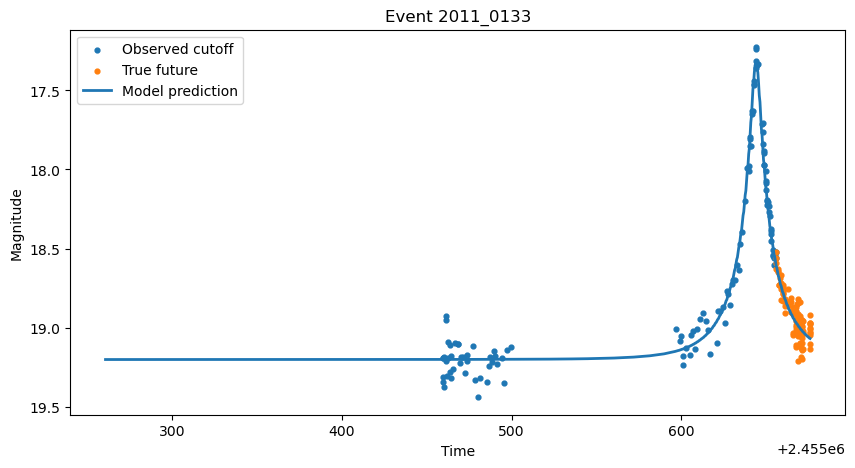


[2/673] Fitting 2011_0135


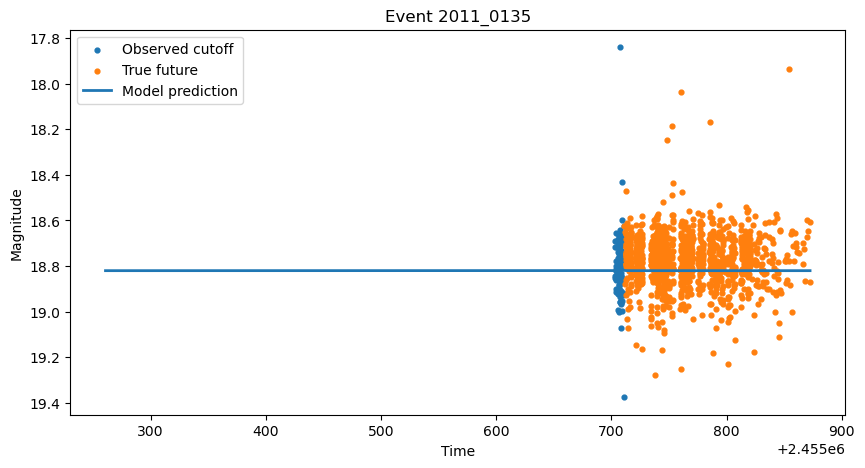


[3/673] Fitting 2011_0153


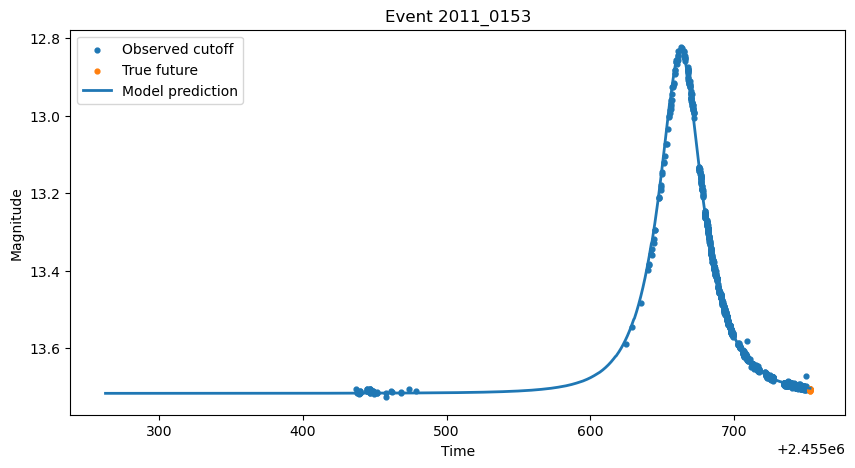


[4/673] Fitting 2011_0164


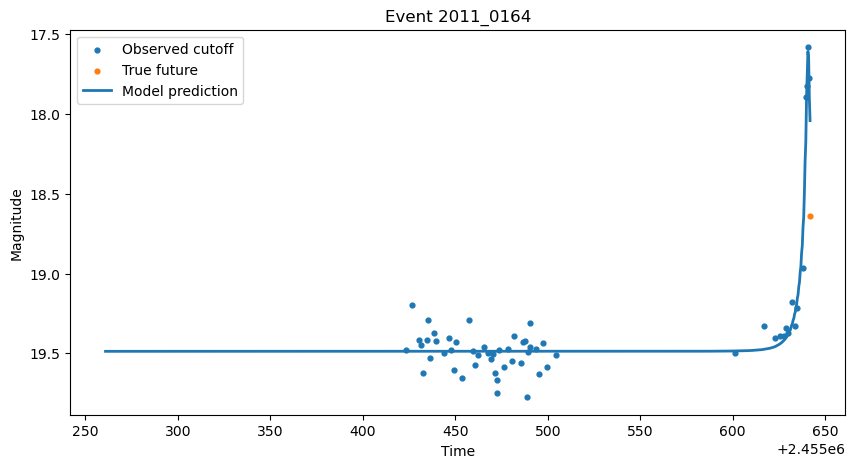


[5/673] Fitting 2011_0199


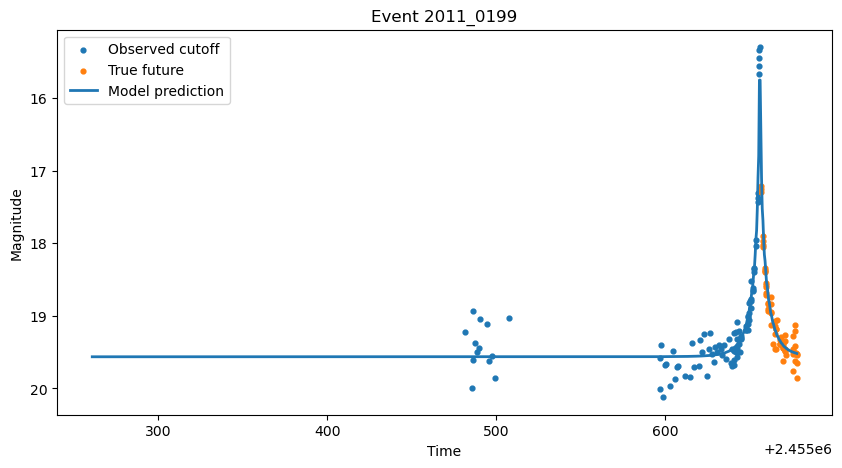


[6/673] Fitting 2011_0231

[7/673] Fitting 2011_0234

[8/673] Fitting 2011_0288

[9/673] Fitting 2011_0296

[10/673] Fitting 2011_0305

[11/673] Fitting 2011_0329

[12/673] Fitting 2011_0331

[13/673] Fitting 2011_0335

[14/673] Fitting 2011_0341

[15/673] Fitting 2011_0344

[16/673] Fitting 2011_0349

[17/673] Fitting 2011_0350

[18/673] Fitting 2011_0355

[19/673] Fitting 2011_0384

[20/673] Fitting 2011_0392

[21/673] Fitting 2011_0487

[22/673] Fitting 2011_0499

[23/673] Fitting 2011_0507

[24/673] Fitting 2011_0536

[25/673] Fitting 2011_0550

[26/673] Fitting 2011_0554

[27/673] Fitting 2011_0561

[28/673] Fitting 2011_0568

[29/673] Fitting 2011_0626

[30/673] Fitting 2011_0688

[31/673] Fitting 2011_0692

[32/673] Fitting 2011_0709

[33/673] Fitting 2011_0774

[34/673] Fitting 2011_0796

[35/673] Fitting 2011_0950

[36/673] Fitting 2011_0964

[37/673] Fitting 2011_0978

[38/673] Fitting 2011_0997

[39/673] Fitting 2011_1000

[40/673] Fitting 2011_1002

[41/673] Fitting 2011_1

,event_id,year,cutoff_file,full_file,params_file,final_loss,obs_mae,obs_rmse,all_mae,all_rmse,...,true_param_7,true_param_8,true_param_9,true_param_10,true_param_11,true_param_12,true_param_13,true_param_14,true_param_15,true_param_16
0,2011_0133,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,0.007169,0.066257,0.084670,0.072174,0.092614,...,11.987,0.480,2.697,0.000,0.441,0.018,19.185,0.001,20.074,0.046
1,2011_0135,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,0.021850,0.090724,0.147816,0.097083,0.132040,...,3.930,0.583,1.486,0.000,0.314,0.060,18.743,0.001,20.001,0.210
2,2011_0153,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,0.000045,0.004142,0.006685,0.003975,0.005837,...,2.463,0.012,0.979,0.000,0.857,0.006,13.714,0.000,13.881,0.008
3,2011_0164,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,0.012180,0.084107,0.110362,0.086815,0.112501,...,99502.600,12.495,0.000,0.116,0.020,19.454,0.004,21.795,0.196,NaN
4,2011_0199,2011,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,/Users/andrewwang/Downloads/LIGHT/testing 3 cu...,0.042279,0.151832,0.205618,0.152446,0.202078,...,64.863,2.211,4.530,0.000,0.707,0.024,19.461,0.002,19.837,0.040



Overall summary:


,obs_mae,obs_rmse,all_mae,all_rmse,future_mae,future_rmse,future_r2
count,673.000000,673.000000,673.000000,673.000000,650.000000,650.000000,571.000000
mean,0.049915,0.065468,0.059327,0.077173,0.104845,0.121571,-33.187902
std,0.032943,0.043478,0.043614,0.054848,0.195654,0.212005,382.736576
min,0.003815,0.005083,0.003975,0.005361,0.000578,0.000578,-8479.718770
25%,0.024193,0.032294,0.026998,0.035308,0.028623,0.033428,-1.144835
50%,0.044687,0.057941,0.050070,0.065949,0.059859,0.070726,-0.037747
75%,0.067566,0.089080,0.083068,0.107861,0.104898,0.125278,0.665083
max,0.221833,0.306370,0.267564,0.302991,2.780835,2.780835,0.998924



By-year summary:


,future_mae,future_rmse,future_r2
year,,,
2011,0.095930,0.112361,-65.134519
2012,0.117487,0.132984,-48.364040
2013,0.135111,0.153114,-17.839109
2014,0.077553,0.094038,-7.199589
2015,0.105474,0.123325,-3.588538
2016,0.083332,0.101450,-21.953310
2017,0.084110,0.102467,-9.775463
2018,0.112618,0.130898,-143.533440
2019,0.091881,0.101751,-9.869269



Failures:


""



Saved files:
parameter_comparison_table_seed67.csv
parameter_summary_overall_seed67.csv
parameter_summary_by_year_seed67.csv


In [2]:

# ============================
# CELL 2: FIT PACZYNSKI MODEL TO EACH GENERATED CUTOFF AND EVALUATE FUTURE PERFORMANCE
# ============================

import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ----------------------------
# CONFIG
# ----------------------------

BASE_DIR = Path.cwd()
LIMIT = None           # Use 3 or 5 for a quick test; None for all generated cutoffs
NUM_EPOCHS = 3000
LR = 0.01
PLOT_FIRST_N = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("BASE_DIR:", BASE_DIR)

# ----------------------------
# FILE HELPERS
# ----------------------------

def extract_event_id(filename):
    name = Path(filename).name
    match = re.search(r"(20\d{2}_\d+)", name)
    if match is None:
        return None
    return match.group(1)


def find_event_triplets(base_dir):
    base_dir = Path(base_dir)

    cutoff_files = list(base_dir.glob("curve_*_cutoff.dat"))
    full_curve_files = [p for p in base_dir.glob("**/curve_*.dat") if "_cutoff" not in p.name]
    param_files = list(base_dir.glob("**/params_*.dat"))

    # Prefer full/params files that live in subfolders, but recursively works either way.
    full_by_id = {}
    for f in full_curve_files:
        event_id = extract_event_id(f)
        if event_id is not None:
            full_by_id[event_id] = f

    params_by_id = {}
    for f in param_files:
        event_id = extract_event_id(f)
        if event_id is not None:
            params_by_id[event_id] = f

    triplets = []

    for cutoff in cutoff_files:
        event_id = extract_event_id(cutoff)
        if event_id in full_by_id and event_id in params_by_id:
            year = int(event_id.split("_")[0])
            triplets.append({
                "event_id": event_id,
                "year": year,
                "cutoff_file": cutoff,
                "full_file": full_by_id[event_id],
                "params_file": params_by_id[event_id],
            })

    triplets = sorted(triplets, key=lambda x: x["event_id"])

    if LIMIT is not None:
        triplets = triplets[:LIMIT]

    print(f"Found cutoff files: {len(cutoff_files)}")
    print(f"Found full curve files: {len(full_curve_files)}")
    print(f"Found params files: {len(param_files)}")
    print(f"Matched complete triplets: {len(triplets)}")

    if len(triplets) == 0:
        print("No complete triplets found. Check BASE_DIR and cutoff generation.")

    return triplets


def robust_load_dat(path):
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if len(line) == 0 or line.startswith("#") or line.lower().startswith("col"):
                continue
            parts = line.split()
            try:
                nums = [float(x) for x in parts]
                if len(nums) >= 2:
                    rows.append(nums)
            except Exception:
                continue

    if len(rows) == 0:
        raise ValueError(f"No numerical data found in {path}")

    return np.array(rows, dtype=float)


def load_true_params(path):
    # Flexible parser: stores named params if available, and also numerical sequence.
    named = {}
    vals = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if len(line) == 0 or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    named[parts[0]] = float(parts[1])
                except Exception:
                    pass
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass

    out = {}
    for k, v in named.items():
        out[k] = v
    for i, v in enumerate(vals):
        out[f"param_{i}"] = v
    return out

# ----------------------------
# MICROLENSING MODEL
# ----------------------------

class MicrolensingModel(nn.Module):
    """
    Differentiable Paczynski single-lens microlensing model.
    Fitted separately for each event.
    """

    def __init__(self, t_obs, m_obs):
        super().__init__()

        t_obs = np.asarray(t_obs)
        m_obs = np.asarray(m_obs)

        baseline_guess = np.median(m_obs)
        peak_idx = np.argmin(m_obs)  # lower mag = brighter
        t0_guess = t_obs[peak_idx]

        t_range = max(t_obs.max() - t_obs.min(), 1.0)
        tau_guess = max(t_range / 5, 1.0)

        self.t0 = nn.Parameter(torch.tensor(float(t0_guess), dtype=torch.float32))
        self.log_tE = nn.Parameter(torch.tensor(np.log(tau_guess), dtype=torch.float32))
        self.log_u0 = nn.Parameter(torch.tensor(np.log(0.5), dtype=torch.float32))
        self.I0 = nn.Parameter(torch.tensor(float(baseline_guess), dtype=torch.float32))
        self.fbl_raw = nn.Parameter(torch.tensor(2.0, dtype=torch.float32))

    def forward(self, t):
        tE = torch.exp(self.log_tE) + 1e-6
        u0 = torch.exp(self.log_u0) + 1e-6
        fbl = torch.sigmoid(self.fbl_raw)

        u = torch.sqrt(u0 ** 2 + ((t - self.t0) / tE) ** 2 + 1e-8)
        A = (u ** 2 + 2) / (u * torch.sqrt(u ** 2 + 4))
        flux_factor = fbl * A + (1 - fbl)
        mag = self.I0 - 2.5 * torch.log10(flux_factor + 1e-8)
        return mag

    def get_params(self):
        with torch.no_grad():
            return {
                "t0": float(self.t0.cpu()),
                "tE": float(torch.exp(self.log_tE).cpu()),
                "u0": float(torch.exp(self.log_u0).cpu()),
                "I0": float(self.I0.cpu()),
                "fbl": float(torch.sigmoid(self.fbl_raw).cpu()),
            }

# ----------------------------
# FIT / EVAL FUNCTIONS
# ----------------------------

def prepare_single_event(cutoff_file, full_file):
    cutoff_data = robust_load_dat(cutoff_file)
    full_data = robust_load_dat(full_file)

    t_obs = cutoff_data[:, 0]
    m_obs = cutoff_data[:, 1]
    t_all = full_data[:, 0]
    m_all = full_data[:, 1]

    cutoff_end = t_obs.max()
    future_mask = t_all > cutoff_end
    t_future = t_all[future_mask]
    m_future = m_all[future_mask]

    return {
        "t_obs": t_obs,
        "m_obs": m_obs,
        "t_all": t_all,
        "m_all": m_all,
        "t_future": t_future,
        "m_future": m_future,
        "cutoff_end": cutoff_end,
    }


def fit_single_event(event_dict, num_epochs=3000, lr=0.01, verbose=False):
    t_obs = event_dict["t_obs"]
    m_obs = event_dict["m_obs"]

    model = MicrolensingModel(t_obs, m_obs).to(device)

    t_tensor = torch.tensor(t_obs, dtype=torch.float32, device=device)
    m_tensor = torch.tensor(m_obs, dtype=torch.float32, device=device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    loss_history = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        pred = model(t_tensor)
        loss = loss_fn(pred, m_tensor)
        loss.backward()
        optimizer.step()
        loss_history.append(float(loss.detach().cpu()))

        if verbose and epoch % 500 == 0:
            print(f"Epoch {epoch}: loss = {loss_history[-1]:.6f}")

    return model, model.get_params(), loss_history


def evaluate_event(model, event_dict):
    t_obs = event_dict["t_obs"]
    m_obs = event_dict["m_obs"]
    t_future = event_dict["t_future"]
    m_future = event_dict["m_future"]
    t_all = event_dict["t_all"]
    m_all = event_dict["m_all"]

    metrics = {}

    with torch.no_grad():
        t_obs_tensor = torch.tensor(t_obs, dtype=torch.float32, device=device)
        pred_obs = model(t_obs_tensor).cpu().numpy()
        metrics["obs_mae"] = np.mean(np.abs(pred_obs - m_obs))
        metrics["obs_rmse"] = np.sqrt(np.mean((pred_obs - m_obs) ** 2))

        t_all_tensor = torch.tensor(t_all, dtype=torch.float32, device=device)
        pred_all = model(t_all_tensor).cpu().numpy()
        metrics["all_mae"] = np.mean(np.abs(pred_all - m_all))
        metrics["all_rmse"] = np.sqrt(np.mean((pred_all - m_all) ** 2))

        if len(t_future) > 0:
            t_future_tensor = torch.tensor(t_future, dtype=torch.float32, device=device)
            pred_future = model(t_future_tensor).cpu().numpy()
            metrics["future_mae"] = np.mean(np.abs(pred_future - m_future))
            metrics["future_rmse"] = np.sqrt(np.mean((pred_future - m_future) ** 2))
            ss_res = np.sum((m_future - pred_future) ** 2)
            ss_tot = np.sum((m_future - np.mean(m_future)) ** 2)
            metrics["future_r2"] = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            metrics["num_future_points"] = len(t_future)
        else:
            metrics["future_mae"] = np.nan
            metrics["future_rmse"] = np.nan
            metrics["future_r2"] = np.nan
            metrics["num_future_points"] = 0

    return metrics


def plot_event_fit(model, event_dict, title):
    t_obs = event_dict["t_obs"]
    m_obs = event_dict["m_obs"]
    t_future = event_dict["t_future"]
    m_future = event_dict["m_future"]
    t_all = event_dict["t_all"]

    t_grid = np.linspace(t_all.min(), t_all.max(), 1000)

    with torch.no_grad():
        t_grid_tensor = torch.tensor(t_grid, dtype=torch.float32, device=device)
        pred_grid = model(t_grid_tensor).cpu().numpy()

    plt.figure(figsize=(10, 5))
    plt.scatter(t_obs, m_obs, s=12, label="Observed cutoff")
    plt.scatter(t_future, m_future, s=12, label="True future")
    plt.plot(t_grid, pred_grid, linewidth=2, label="Model prediction")
    plt.gca().invert_yaxis()
    plt.xlabel("Time")
    plt.ylabel("Magnitude")
    plt.title(title)
    plt.legend()
    plt.show()

# ----------------------------
# BATCH RUNNER
# ----------------------------

def run_batch_parameter_table():
    triplets = find_event_triplets(BASE_DIR)
    all_rows = []
    failures = []

    for i, item in enumerate(triplets):
        event_id = item["event_id"]
        year = item["year"]
        cutoff_file = item["cutoff_file"]
        full_file = item["full_file"]
        params_file = item["params_file"]

        print(f"\n[{i+1}/{len(triplets)}] Fitting {event_id}")

        try:
            event_dict = prepare_single_event(cutoff_file, full_file)
            model, fitted_params, loss_history = fit_single_event(
                event_dict,
                num_epochs=NUM_EPOCHS,
                lr=LR,
                verbose=False,
            )
            metrics = evaluate_event(model, event_dict)
            true_params = load_true_params(params_file)

            row = {
                "event_id": event_id,
                "year": year,
                "cutoff_file": str(cutoff_file),
                "full_file": str(full_file),
                "params_file": str(params_file),
                "final_loss": loss_history[-1],
                **metrics,
            }

            for k, v in fitted_params.items():
                row[f"fit_{k}"] = v
            for k, v in true_params.items():
                row[f"true_{k}"] = v

            all_rows.append(row)

            if i < PLOT_FIRST_N:
                plot_event_fit(model, event_dict, title=f"Event {event_id}")

        except Exception as e:
            print(f"FAILED {event_id}: {e}")
            failures.append({
                "event_id": event_id,
                "error": str(e),
                "cutoff_file": str(cutoff_file),
                "full_file": str(full_file),
                "params_file": str(params_file),
            })

    results_df = pd.DataFrame(all_rows)
    failures_df = pd.DataFrame(failures)

    if len(results_df) > 0:
        results_df.to_csv("parameter_comparison_table_seed67.csv", index=False)

        overall_summary = results_df[[
            "obs_mae", "obs_rmse", "all_mae", "all_rmse", "future_mae", "future_rmse", "future_r2"
        ]].describe()
        overall_summary.to_csv("parameter_summary_overall_seed67.csv")

        by_year_summary = results_df.groupby("year")[["future_mae", "future_rmse", "future_r2"]].mean()
        by_year_summary.to_csv("parameter_summary_by_year_seed67.csv")
    else:
        overall_summary = pd.DataFrame()
        by_year_summary = pd.DataFrame()

    if len(failures_df) > 0:
        failures_df.to_csv("failed_events_seed67.csv", index=False)

    return results_df, failures_df, overall_summary, by_year_summary

results_df, failures_df, overall_summary, by_year_summary = run_batch_parameter_table()

print("\n============================")
print("DONE")
print("============================")
print("\nResults:")
display(results_df.head())
print("\nOverall summary:")
display(overall_summary)
print("\nBy-year summary:")
display(by_year_summary)
print("\nFailures:")
display(failures_df)

print("\nSaved files:")
print("parameter_comparison_table_seed67.csv")
print("parameter_summary_overall_seed67.csv")
print("parameter_summary_by_year_seed67.csv")
if len(failures_df) > 0:
    print("failed_events_seed67.csv")


ALL EVENTS RANKED BY FUTURE R²


,event_id,year,future_r2,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse,final_loss,fit_t0,fit_tE,fit_u0,fit_I0,fit_fbl
0,2024_0886,2024,0.998924,0.003312,0.003346,0.020728,0.028108,0.021304,0.028681,0.000790,2460505.75,106.737137,0.278571,17.973011,0.513038
1,2018_0421,2018,0.998779,0.007021,0.009344,0.005817,0.008085,0.006385,0.010121,0.000065,2458224.00,16.092712,0.087249,15.868814,0.972552
2,2018_1074,2018,0.998023,0.016661,0.018704,0.030501,0.037631,0.036539,0.045986,0.001416,2458314.75,55.209766,0.025061,17.974361,0.979200
3,2012_0644,2012,0.997367,0.031604,0.041101,0.034070,0.043773,0.035778,0.044294,0.001916,2456066.50,11.121756,0.036973,18.376698,0.593417
4,2018_0808,2018,0.997314,0.007594,0.009507,0.006174,0.008379,0.007228,0.008896,0.000070,2458305.75,27.825630,0.341760,15.188169,0.868747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668,2024_0633,2024,NaN,NaN,NaN,0.047804,0.059398,0.056806,0.073368,0.003528,2460449.75,20.417006,0.455953,18.837477,0.514015
669,2024_0848,2024,NaN,NaN,NaN,0.046532,0.087772,0.033224,0.044318,0.007704,2460502.00,19.845032,0.018265,18.014763,0.105149
670,2024_0893,2024,NaN,0.027631,0.027631,0.034182,0.043743,0.039170,0.051413,0.001914,2460494.75,42.988144,0.218568,18.646137,0.343183
671,2024_0895,2024,NaN,0.008620,0.008620,0.015996,0.021018,0.018917,0.023882,0.000442,2460488.75,5.229792,0.705805,17.320944,0.738068



TOP EVENTS BY FUTURE R²


,event_id,year,future_r2,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse,final_loss,fit_t0,fit_tE,fit_u0,fit_I0,fit_fbl
0,2024_0886,2024,0.998924,0.003312,0.003346,0.020728,0.028108,0.021304,0.028681,0.000790,2460505.75,106.737137,0.278571,17.973011,0.513038
1,2018_0421,2018,0.998779,0.007021,0.009344,0.005817,0.008085,0.006385,0.010121,0.000065,2458224.00,16.092712,0.087249,15.868814,0.972552
2,2018_1074,2018,0.998023,0.016661,0.018704,0.030501,0.037631,0.036539,0.045986,0.001416,2458314.75,55.209766,0.025061,17.974361,0.979200
3,2012_0644,2012,0.997367,0.031604,0.041101,0.034070,0.043773,0.035778,0.044294,0.001916,2456066.50,11.121756,0.036973,18.376698,0.593417
4,2018_0808,2018,0.997314,0.007594,0.009507,0.006174,0.008379,0.007228,0.008896,0.000070,2458305.75,27.825630,0.341760,15.188169,0.868747



WORST EVENTS BY FUTURE R²


...


CORRELATION TABLE


,future_r2,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse,final_loss,fit_tE,fit_u0,fit_fbl
future_r2,1.000000,-0.122904,-0.086626,-0.027287,-0.022538,0.017141,0.017771,-0.009455,0.045709,0.019848,0.067383
future_mae,-0.122904,1.000000,0.987564,0.210001,0.210766,0.190064,0.304948,0.193366,0.079184,-0.128427,-0.190226
future_rmse,-0.086626,0.987564,1.000000,0.231564,0.232445,0.216378,0.332506,0.214912,0.071778,-0.125081,-0.199686
obs_mae,-0.027287,0.210001,0.231564,1.000000,0.990772,0.856558,0.867215,0.910532,0.002685,-0.190999,-0.183370
obs_rmse,-0.022538,0.210766,0.232445,0.990772,1.000000,0.844979,0.858692,0.927060,-0.002586,-0.175883,-0.177110
all_mae,0.017141,0.190064,0.216378,0.856558,0.844979,1.000000,0.986297,0.739410,0.018407,-0.154851,-0.123148
all_rmse,0.017771,0.304948,0.332506,0.867215,0.858692,0.986297,1.000000,0.753663,0.026746,-0.169487,-0.143751
final_loss,-0.009455,0.193366,0.214912,0.910532,0.927060,0.739410,0.753663,1.000000,-0.016788,-0.005060,-0.113705
fit_tE,0.045709,0.079184,0.071778,0.002685,-0.002586,0.018407,0.026746,-0.016788,1.000000,-0.246107,-0.301287
fit_u0,0.019848,-0.128427,-0.125081,-0.190999,-0.175883,-0.154851,-0.169487,-0.005060,-0.246107,1.000000,0.327564



Most relevant correlations with future_r2:


,correlation_with_future_r2
future_mae,-0.122904
future_rmse,-0.086626
obs_mae,-0.027287
obs_rmse,-0.022538
final_loss,-0.009455
all_mae,0.017141
all_rmse,0.017771
fit_u0,0.019848
fit_tE,0.045709
fit_fbl,0.067383



Saved deeper analysis CSVs with _seed67 suffix.


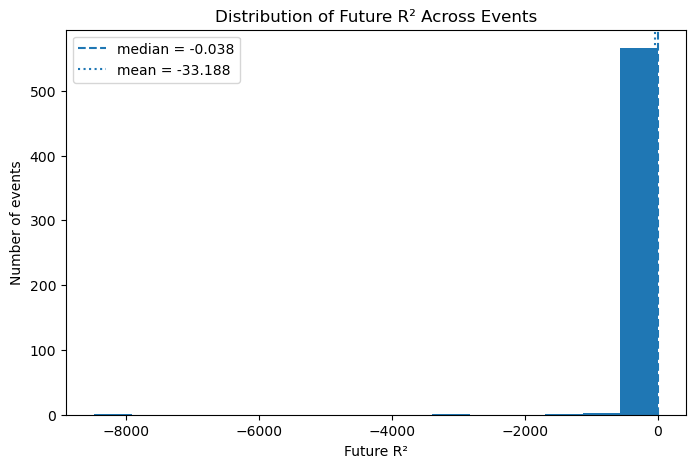

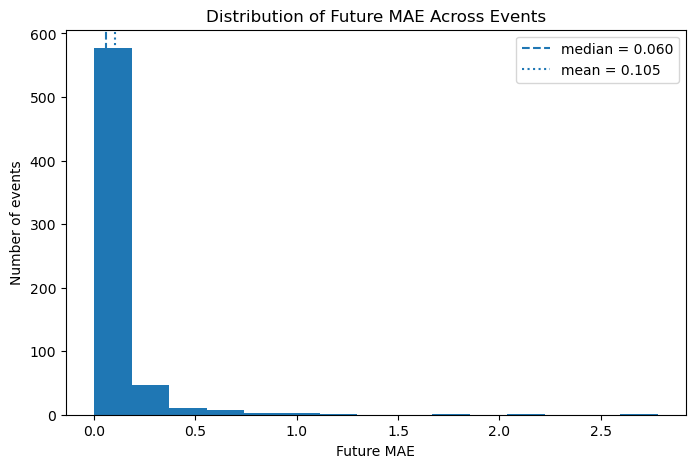

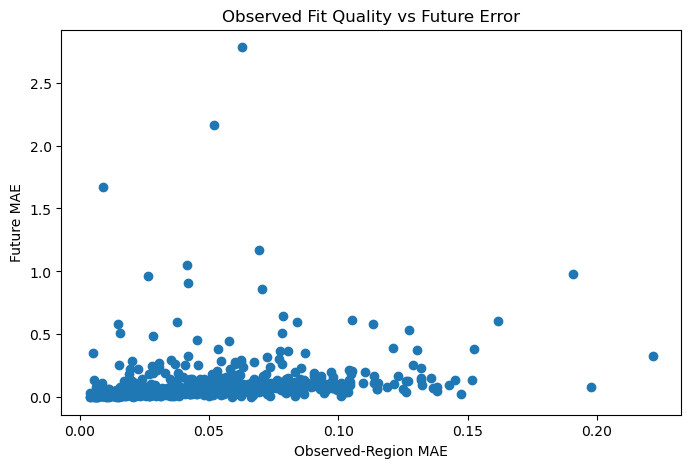

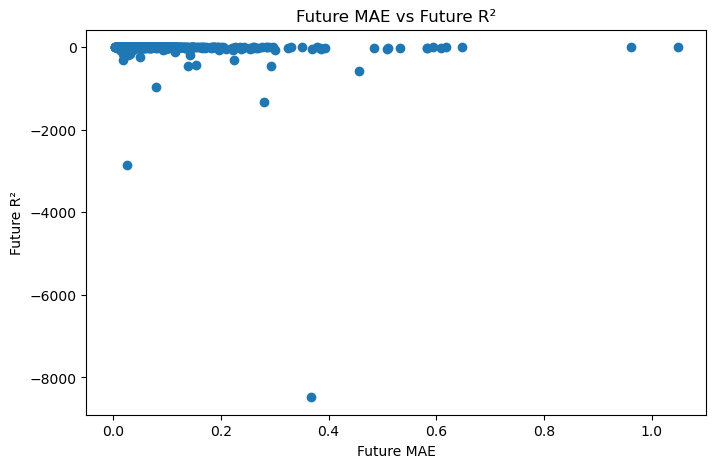

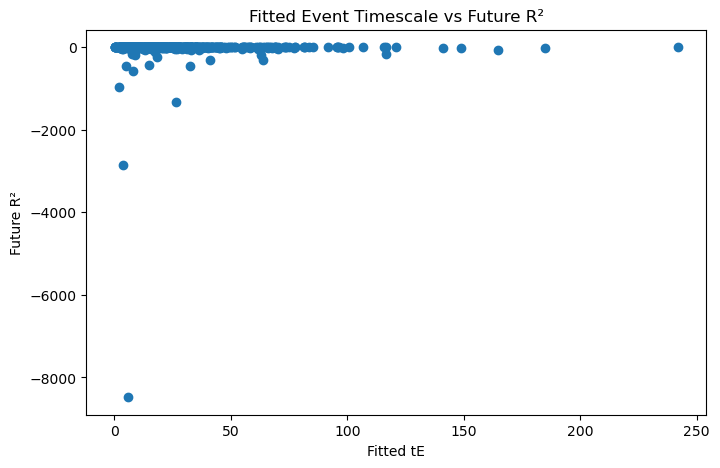

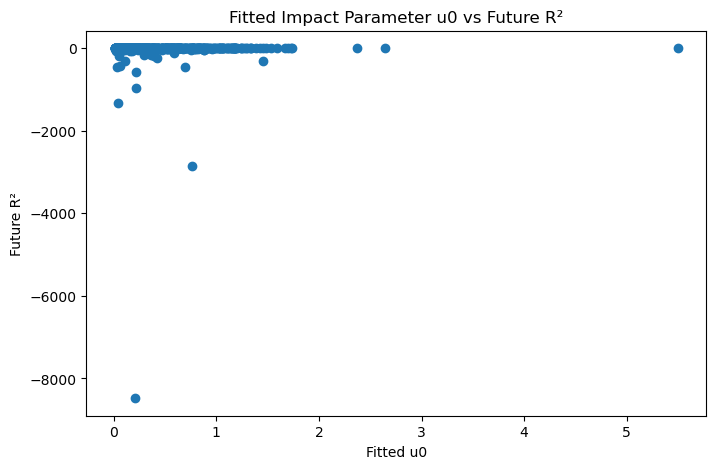


PLOTTING TOP EVENTS BY FUTURE R²


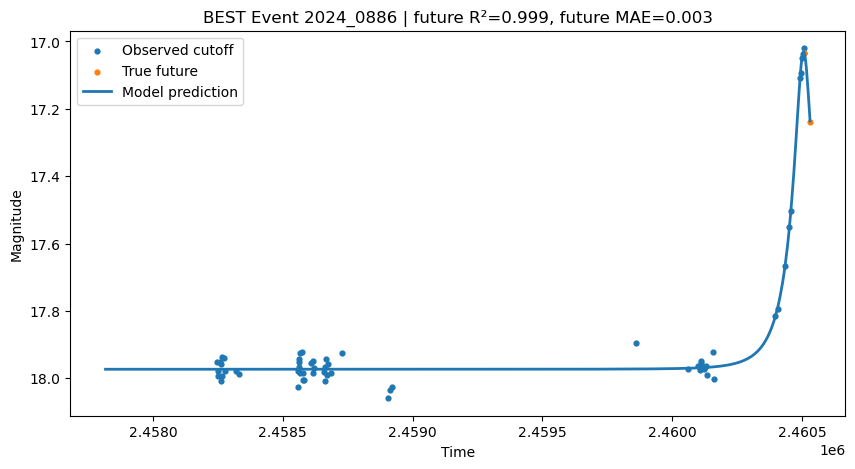

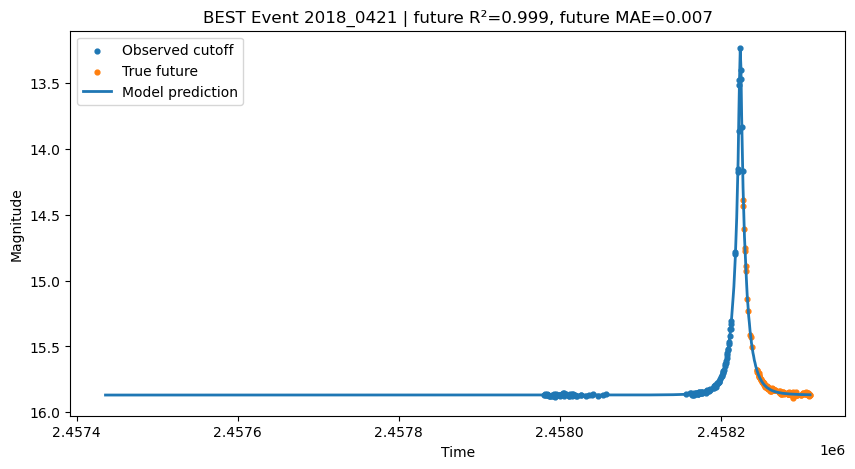

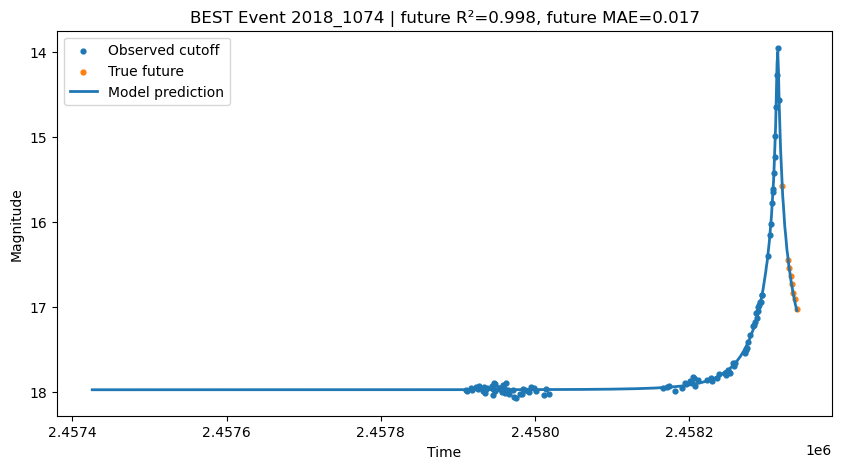

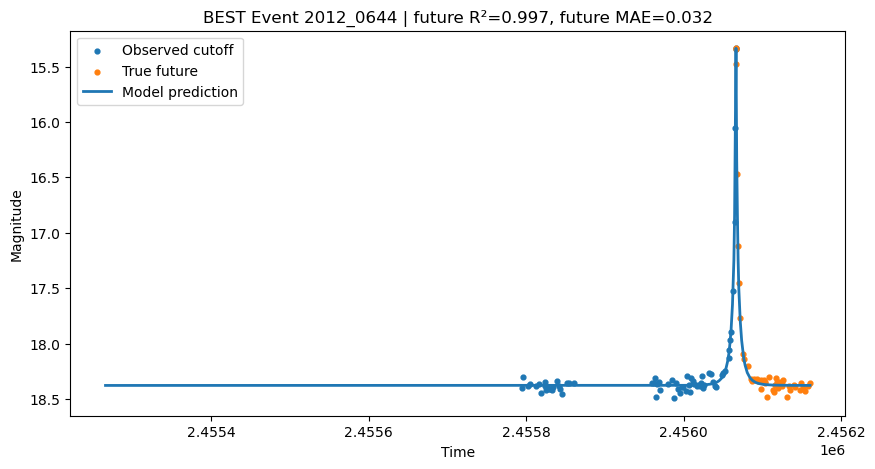

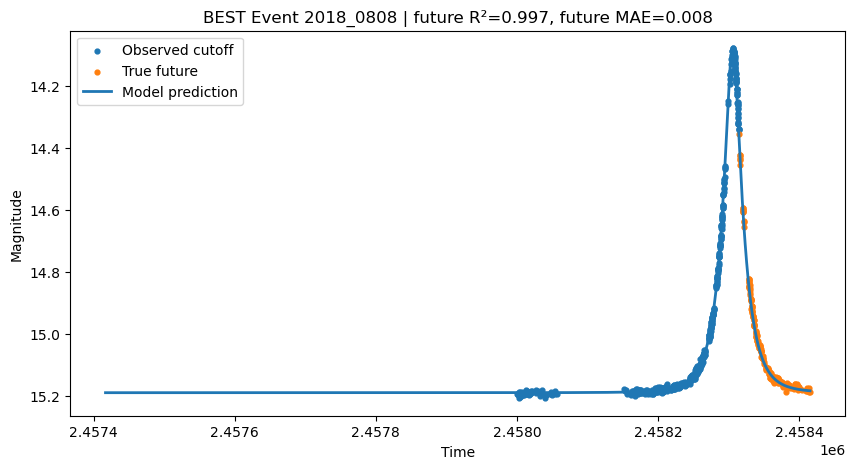


PLOTTING WORST EVENTS BY FUTURE R²


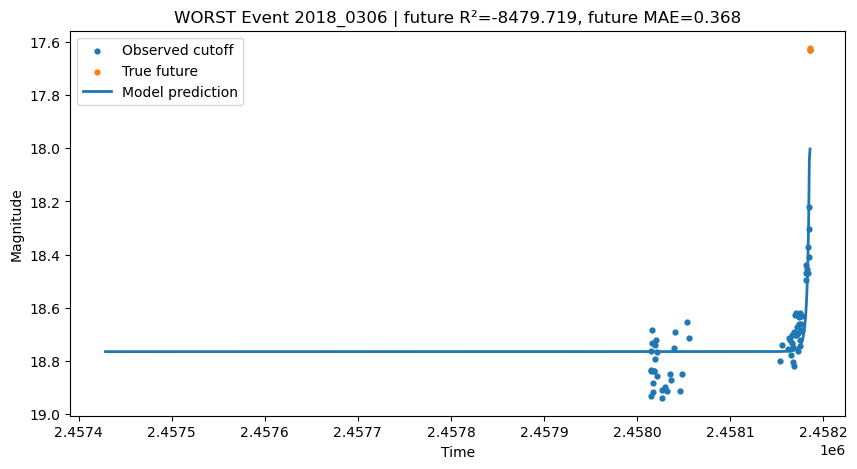

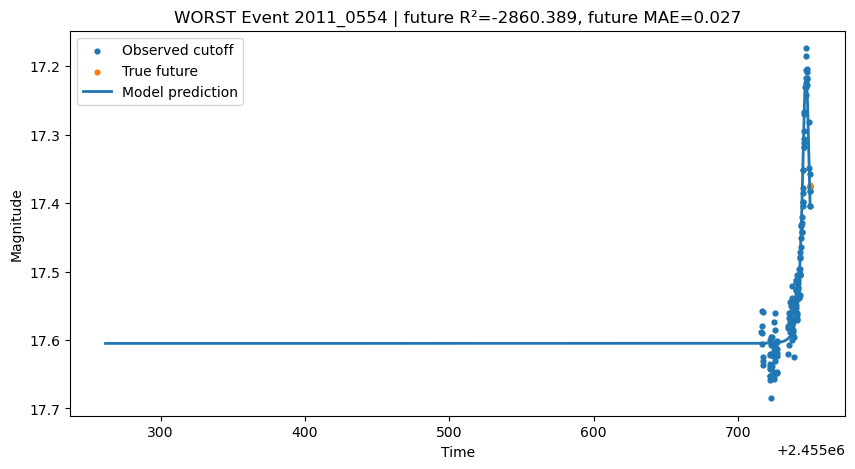

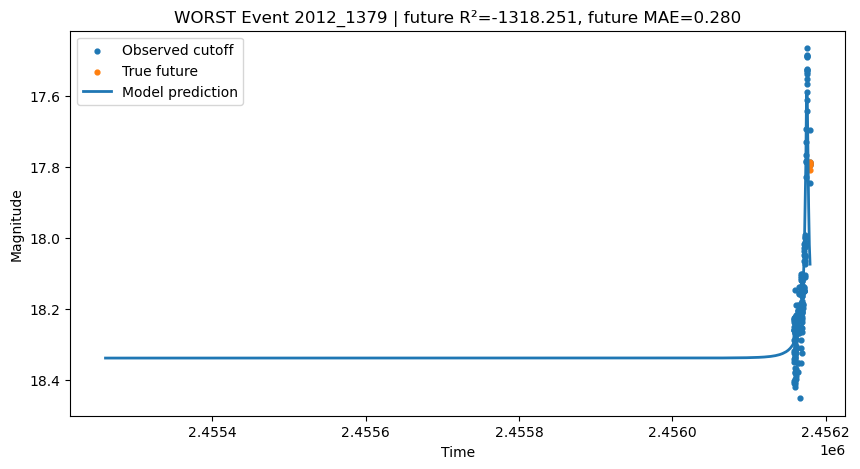

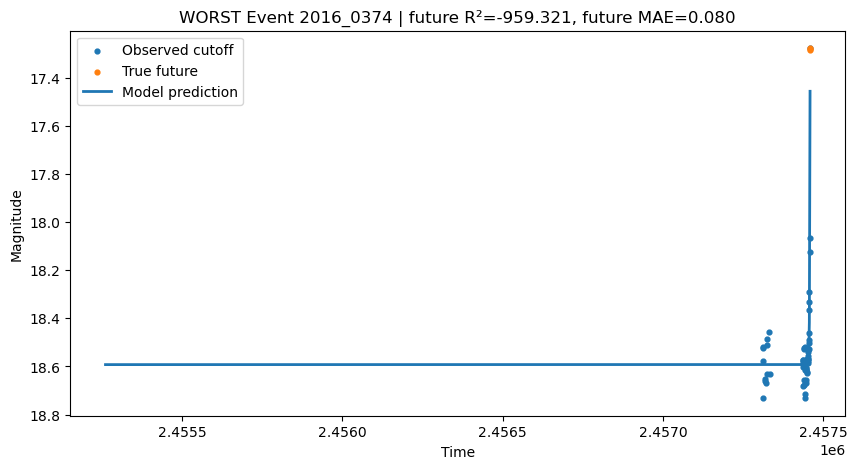

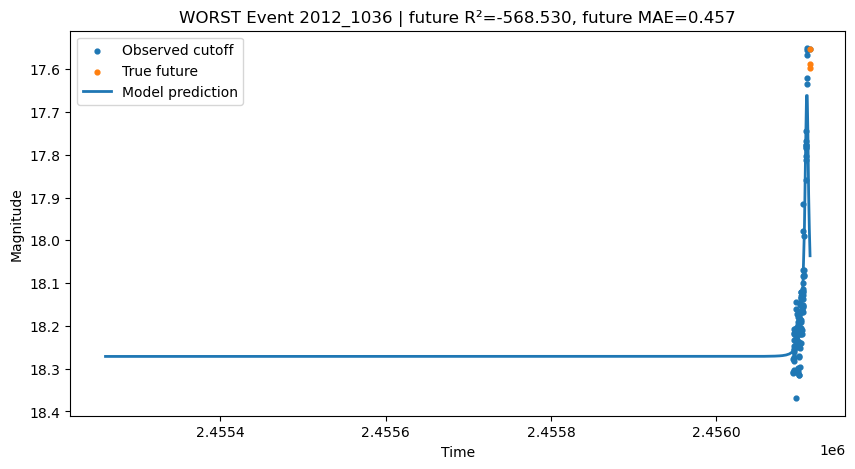


DEEP ANALYSIS DONE


In [3]:

# ============================
# CELL 3: DEEPER ANALYSIS, OUTLIERS, AND BEST/WORST PLOTS
# Run after Cell 2
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_BEST = 5
N_WORST = 5
PLOT_BEST = True
PLOT_WORST = True

if "results_df" not in globals():
    raise RuntimeError("results_df not found. Run Cell 2 first.")
if len(results_df) == 0:
    raise RuntimeError("results_df is empty.")

df = results_df.copy()

numeric_cols = [
    "obs_mae", "obs_rmse", "all_mae", "all_rmse",
    "future_mae", "future_rmse", "future_r2", "final_loss",
    "fit_t0", "fit_tE", "fit_u0", "fit_I0", "fit_fbl",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

ranked_by_r2 = df.sort_values("future_r2", ascending=False).reset_index(drop=True)
ranked_by_mae = df.sort_values("future_mae", ascending=True).reset_index(drop=True)
worst_by_r2 = df.sort_values("future_r2", ascending=True).reset_index(drop=True)
worst_by_mae = df.sort_values("future_mae", ascending=False).reset_index(drop=True)

display_cols = [
    "event_id", "year", "future_r2", "future_mae", "future_rmse",
    "obs_mae", "obs_rmse", "all_mae", "all_rmse", "final_loss",
    "fit_t0", "fit_tE", "fit_u0", "fit_I0", "fit_fbl",
]
display_cols = [c for c in display_cols if c in df.columns]

print("================================")
print("ALL EVENTS RANKED BY FUTURE R²")
print("================================")
display(ranked_by_r2[display_cols])

print("\nTOP EVENTS BY FUTURE R²")
display(ranked_by_r2.head(N_BEST)[display_cols])

print("\nWORST EVENTS BY FUTURE R²")
display(worst_by_r2.head(N_WORST)[display_cols])

print("\nBEST EVENTS BY FUTURE MAE")
display(ranked_by_mae.head(N_BEST)[display_cols])

print("\nWORST EVENTS BY FUTURE MAE")
display(worst_by_mae.head(N_WORST)[display_cols])

summary_metrics = ["obs_mae", "obs_rmse", "all_mae", "all_rmse", "future_mae", "future_rmse", "future_r2"]
summary_metrics = [c for c in summary_metrics if c in df.columns]

deep_summary = df[summary_metrics].agg([
    "count", "mean", "median", "std", "min",
    lambda x: x.quantile(0.10),
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    lambda x: x.quantile(0.90),
    "max",
])
deep_summary.index = ["count", "mean", "median", "std", "min", "10%", "25%", "75%", "90%", "max"]

print("\nDEEP SUMMARY STATS")
display(deep_summary)

# R² buckets

def r2_bucket(r2):
    if pd.isna(r2): return "NaN"
    if r2 >= 0.90: return "excellent: R² >= 0.90"
    if r2 >= 0.75: return "strong: 0.75 <= R² < 0.90"
    if r2 >= 0.50: return "decent: 0.50 <= R² < 0.75"
    if r2 >= 0.00: return "weak: 0.00 <= R² < 0.50"
    return "bad: R² < 0"

df["r2_bucket"] = df["future_r2"].apply(r2_bucket)
r2_bucket_counts = df["r2_bucket"].value_counts().reindex([
    "excellent: R² >= 0.90",
    "strong: 0.75 <= R² < 0.90",
    "decent: 0.50 <= R² < 0.75",
    "weak: 0.00 <= R² < 0.50",
    "bad: R² < 0",
    "NaN",
]).dropna()
print("\nFUTURE R² BUCKET COUNTS")
display(r2_bucket_counts.to_frame("count"))

# Outliers
r2_q1 = df["future_r2"].quantile(0.25)
r2_q3 = df["future_r2"].quantile(0.75)
r2_iqr = r2_q3 - r2_q1
r2_lower_fence = r2_q1 - 1.5 * r2_iqr
mae_q1 = df["future_mae"].quantile(0.25)
mae_q3 = df["future_mae"].quantile(0.75)
mae_iqr = mae_q3 - mae_q1
mae_upper_fence = mae_q3 + 1.5 * mae_iqr

r2_outliers = df[df["future_r2"] < r2_lower_fence].sort_values("future_r2")
mae_outliers = df[df["future_mae"] > mae_upper_fence].sort_values("future_mae", ascending=False)

print("\nR² OUTLIER THRESHOLD")
print(f"R² Q1: {r2_q1:.4f}")
print(f"R² Q3: {r2_q3:.4f}")
print(f"R² IQR: {r2_iqr:.4f}")
print(f"Lower outlier fence: {r2_lower_fence:.4f}")
print("Bad R² outliers:")
display(r2_outliers[display_cols])

print("\nFUTURE MAE OUTLIER THRESHOLD")
print(f"Future MAE Q1: {mae_q1:.4f}")
print(f"Future MAE Q3: {mae_q3:.4f}")
print(f"Future MAE IQR: {mae_iqr:.4f}")
print(f"Upper outlier fence: {mae_upper_fence:.4f}")
print("High future MAE outliers:")
display(mae_outliers[display_cols])

# Year summary
year_summary = df.groupby("year").agg(
    n=("event_id", "count"),
    median_future_r2=("future_r2", "median"),
    mean_future_r2=("future_r2", "mean"),
    min_future_r2=("future_r2", "min"),
    max_future_r2=("future_r2", "max"),
    median_future_mae=("future_mae", "median"),
    mean_future_mae=("future_mae", "mean"),
    median_future_rmse=("future_rmse", "median"),
    mean_future_rmse=("future_rmse", "mean"),
    median_obs_mae=("obs_mae", "median"),
    mean_obs_mae=("obs_mae", "mean"),
).sort_index()
print("\nYEAR-BY-YEAR DEEP SUMMARY")
display(year_summary)

# Correlation
corr_cols = [
    "future_r2", "future_mae", "future_rmse", "obs_mae", "obs_rmse",
    "all_mae", "all_rmse", "final_loss", "fit_tE", "fit_u0", "fit_fbl",
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr_table = df[corr_cols].corr()
print("\nCORRELATION TABLE")
display(corr_table)
print("\nMost relevant correlations with future_r2:")
display(corr_table["future_r2"].sort_values().to_frame("correlation_with_future_r2"))

# Save CSVs
ranked_by_r2.to_csv("deep_ranked_by_future_r2_seed67.csv", index=False)
ranked_by_mae.to_csv("deep_ranked_by_future_mae_seed67.csv", index=False)
worst_by_r2.to_csv("deep_worst_by_future_r2_seed67.csv", index=False)
worst_by_mae.to_csv("deep_worst_by_future_mae_seed67.csv", index=False)
deep_summary.to_csv("deep_summary_stats_seed67.csv")
year_summary.to_csv("deep_year_summary_seed67.csv")
corr_table.to_csv("deep_correlation_table_seed67.csv")
r2_outliers.to_csv("deep_r2_outliers_seed67.csv", index=False)
mae_outliers.to_csv("deep_mae_outliers_seed67.csv", index=False)

print("\nSaved deeper analysis CSVs with _seed67 suffix.")

# Distribution plots
plt.figure(figsize=(8, 5))
plt.hist(df["future_r2"].dropna(), bins=15)
plt.axvline(df["future_r2"].median(), linestyle="--", label=f"median = {df['future_r2'].median():.3f}")
plt.axvline(df["future_r2"].mean(), linestyle=":", label=f"mean = {df['future_r2'].mean():.3f}")
plt.xlabel("Future R²")
plt.ylabel("Number of events")
plt.title("Distribution of Future R² Across Events")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["future_mae"].dropna(), bins=15)
plt.axvline(df["future_mae"].median(), linestyle="--", label=f"median = {df['future_mae'].median():.3f}")
plt.axvline(df["future_mae"].mean(), linestyle=":", label=f"mean = {df['future_mae'].mean():.3f}")
plt.xlabel("Future MAE")
plt.ylabel("Number of events")
plt.title("Distribution of Future MAE Across Events")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["obs_mae"], df["future_mae"])
plt.xlabel("Observed-Region MAE")
plt.ylabel("Future MAE")
plt.title("Observed Fit Quality vs Future Error")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["future_mae"], df["future_r2"])
plt.xlabel("Future MAE")
plt.ylabel("Future R²")
plt.title("Future MAE vs Future R²")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["fit_tE"], df["future_r2"])
plt.xlabel("Fitted tE")
plt.ylabel("Future R²")
plt.title("Fitted Event Timescale vs Future R²")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["fit_u0"], df["future_r2"])
plt.xlabel("Fitted u0")
plt.ylabel("Future R²")
plt.title("Fitted Impact Parameter u0 vs Future R²")
plt.show()

# Refit selected examples for best/worst plots. Previous batch did not store all models.
def refit_and_plot_event(event_id, title_prefix=""):
    matching = df[df["event_id"] == event_id]
    if len(matching) == 0:
        print(f"Event {event_id} not found.")
        return None
    row = matching.iloc[0]
    event_dict = prepare_single_event(row["cutoff_file"], row["full_file"])
    model, fitted_params, loss_history = fit_single_event(
        event_dict,
        num_epochs=NUM_EPOCHS,
        lr=LR,
        verbose=False,
    )
    title = f"{title_prefix} Event {event_id} | future R²={row['future_r2']:.3f}, future MAE={row['future_mae']:.3f}"
    plot_event_fit(model, event_dict, title=title)
    return model, fitted_params, loss_history

if PLOT_BEST:
    print("\nPLOTTING TOP EVENTS BY FUTURE R²")
    for event_id in ranked_by_r2.head(N_BEST)["event_id"]:
        refit_and_plot_event(event_id, title_prefix="BEST")

if PLOT_WORST:
    print("\nPLOTTING WORST EVENTS BY FUTURE R²")
    for event_id in worst_by_r2.head(N_WORST)["event_id"]:
        refit_and_plot_event(event_id, title_prefix="WORST")

print("\nDEEP ANALYSIS DONE")


Total evaluated events: 673

Subset sizes:
Events with future MAE/RMSE: 650
Events with finite R²: 571
Events with reasonable R² [-1, 1]: 420
Events with nonnegative R² [0, 1]: 257
Events with NaN R²: 102
Events with R² < -1: 151

R² interpretation note:
NaN R² usually means the withheld future segment had too little variance or too few useful points.
Extremely negative R² usually means the true future segment was nearly flat, so the R² denominator was tiny.
For these cases, future MAE and future RMSE are more stable than R².

STABLE ERROR SUMMARY: ALL EVENTS WITH FUTURE DATA
Use this for MAE/RMSE reporting


/var/folders/c7/dwkm_jbn6ylgql5z4g9350m00000gn/T/ipykernel_10034/3133994379.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  r2_valid = has_future_error[


,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse
count,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000
mean,0.104845,0.121571,0.049996,0.065533,0.059202,0.077067
median,0.059859,0.070726,0.044359,0.057782,0.050187,0.065956
std,0.195654,0.212005,0.033217,0.043832,0.043612,0.054985
min,0.000578,0.000578,0.003815,0.005083,0.003975,0.005361
10%,0.013474,0.016122,0.013261,0.016934,0.013063,0.018025
25%,0.028623,0.033428,0.024067,0.031996,0.026874,0.034785
75%,0.104898,0.125278,0.068012,0.089040,0.083001,0.107894
90%,0.196544,0.226961,0.093258,0.121314,0.117077,0.149483
max,2.780835,2.780835,0.221833,0.306370,0.267564,0.302991



R² SUMMARY BY SUBSET


,finite_r2_all,reasonable_r2_-1_to_1,nonnegative_r2_0_to_1
count,571.000000,420.000000,257.000000
mean,-33.187902,0.268216,0.627701
std,382.736576,0.546925,0.318608
min,-8479.718770,-0.976813,0.000500
25%,-1.144835,-0.089435,0.405405
50%,-0.037747,0.212669,0.713390
75%,0.665083,0.790211,0.909590
max,0.998924,0.998924,0.998924


...

,event_id,year,future_r2,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse,final_loss,fit_t0,fit_tE,fit_u0,fit_I0,fit_fbl
363,2016_0620,2016,NaN,0.000578,0.000578,0.007079,0.009063,0.008802,0.011104,0.000082,2457534.75,28.897985,0.507745,15.611567,0.792512
342,2016_0018,2016,NaN,0.000891,0.000891,0.015048,0.018736,0.014226,0.018085,0.000351,2457489.75,50.568886,0.843247,17.272152,0.827839
310,2015_1318,2015,NaN,0.001512,0.001512,0.014076,0.018158,0.028131,0.032940,0.000330,2457167.00,11.530851,1.208891,17.139332,0.740883
503,2018_1141,2018,NaN,0.001713,0.001713,0.006737,0.008577,0.007080,0.008857,0.000074,2458311.50,19.403299,0.873712,14.404936,0.741827
650,2024_0543,2024,-0.697492,0.002788,0.003985,0.010280,0.016335,0.005702,0.007622,0.000267,2460440.75,4.190001,0.776513,15.223992,0.792778
246,2014_1248,2014,0.000863,0.002924,0.003844,0.005322,0.006522,0.004228,0.005361,0.000043,2456844.50,8.358866,1.151952,15.186145,0.755701
662,2024_0886,2024,0.998924,0.003312,0.003346,0.020728,0.028108,0.021304,0.028681,0.000790,2460505.75,106.737137,0.278571,17.973011,0.513038
2,2011_0153,2011,-3.502108,0.003414,0.003858,0.004142,0.006685,0.003975,0.005837,0.000045,2455662.75,28.865980,0.428389,13.717001,0.846888
455,2017_1604,2017,0.529049,0.003634,0.003774,0.014996,0.018770,0.017900,0.022805,0.000352,2458016.50,20.020420,0.368243,17.202583,0.574786
281,2015_0410,2015,NaN,0.003747,0.003747,0.006469,0.008595,0.006505,0.008129,0.000074,2457120.00,20.680080,0.262629,16.143908,0.881166



WORST EVENTS BY FUTURE MAE
This is often more meaningful than worst R²


,event_id,year,future_r2,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse,final_loss,fit_t0,fit_tE,fit_u0,fit_I0,fit_fbl
184,2013_1369,2013,NaN,2.780835,2.780835,0.062900,0.081602,0.092463,0.231549,0.006659,2456432.00,79.019241,0.023111,19.219011,0.131369
638,2024_0263,2024,NaN,2.164619,2.164619,0.052120,0.066192,0.055627,0.108535,0.004381,2460396.00,30.242395,0.043144,18.804253,0.271297
472,2018_0293,2018,NaN,1.670164,1.670164,0.008943,0.015028,0.016174,0.120661,0.000226,2458185.00,56.381428,0.043791,16.057941,0.210945
338,2015_2054,2015,NaN,1.169838,1.169838,0.069427,0.084119,0.093944,0.129382,0.007076,2457270.50,19.520893,0.197556,19.233759,0.204393
602,2023_0279,2023,-2.899956,1.049360,1.459400,0.041478,0.051066,0.052766,0.141626,0.002608,2460043.75,7.384017,0.433341,17.781073,0.830298
132,2013_0229,2013,NaN,0.976760,0.976760,0.190891,0.256010,0.158492,0.217105,0.065541,2456351.00,32.717098,0.062455,19.306223,0.946106
430,2017_0944,2017,-1.222190,0.961687,1.358774,0.026520,0.034827,0.038043,0.106280,0.001213,2457901.50,4.512875,0.501220,18.471169,0.689080
564,2019_0862,2019,NaN,0.907226,0.907226,0.042060,0.052645,0.036684,0.066023,0.002772,2458621.75,10.923119,1.084541,18.393522,0.704163
613,2023_0522,2023,NaN,0.857861,0.857861,0.070527,0.086706,0.059399,0.083185,0.007518,2460076.00,11.618031,0.520037,18.974634,0.723954
492,2018_0780,2018,-2.903239,0.647237,0.849535,0.078717,0.099142,0.079700,0.124010,0.009829,2458256.75,30.246845,0.039649,19.298166,0.192960



EXTREME NEGATIVE R² CASES
Good to discuss as R² instability / low future-variance cases


,event_id,year,future_r2,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse,final_loss,fit_t0,fit_tE,fit_u0,fit_I0,fit_fbl
473,2018_0306,2018,-8479.718770,0.368194,0.368363,0.080605,0.101032,0.055405,0.071849,0.010210,2458185.75,5.835480,0.205363,18.765606,0.265217
25,2011_0554,2011,-2860.389035,0.026741,0.026746,0.023431,0.028417,0.029415,0.035930,0.000808,2455747.00,3.477914,0.764539,17.604982,0.741044
110,2012_1379,2012,-1318.250975,0.280299,0.280406,0.062513,0.084888,0.046930,0.060528,0.007206,2456175.50,26.614838,0.045478,18.337866,0.050841
352,2016_0374,2016,-959.321393,0.079810,0.105343,0.050239,0.063601,0.052988,0.068541,0.004045,2457458.75,1.873980,0.218866,18.592373,0.615851
95,2012_1036,2012,-568.530046,0.456714,0.457115,0.045340,0.069221,0.037270,0.050255,0.004792,2456109.75,8.086339,0.214623,18.271332,0.211598
191,2013_1604,2013,-461.831448,0.139419,0.139838,0.042103,0.055782,0.033902,0.044392,0.003112,2456501.50,4.987349,0.697055,17.805470,0.689178
115,2012_1611,2012,-459.909840,0.293698,0.294017,0.062212,0.078841,0.084812,0.108539,0.006216,2456204.75,32.537632,0.029025,19.076714,0.219167
201,2013_1781,2013,-423.134074,0.154277,0.154459,0.131929,0.158483,0.127741,0.169179,0.025117,2456543.50,14.913274,0.059677,19.372934,0.297255
643,2024_0416,2024,-313.623467,0.224092,0.283802,0.019495,0.025002,0.029248,0.042418,0.000625,2460442.75,63.638809,0.106985,17.457771,0.364626
458,2017_1632,2017,-310.768448,0.017610,0.017657,0.004547,0.005701,0.004897,0.006131,0.000033,2458026.50,40.934929,1.453372,15.090302,0.695622


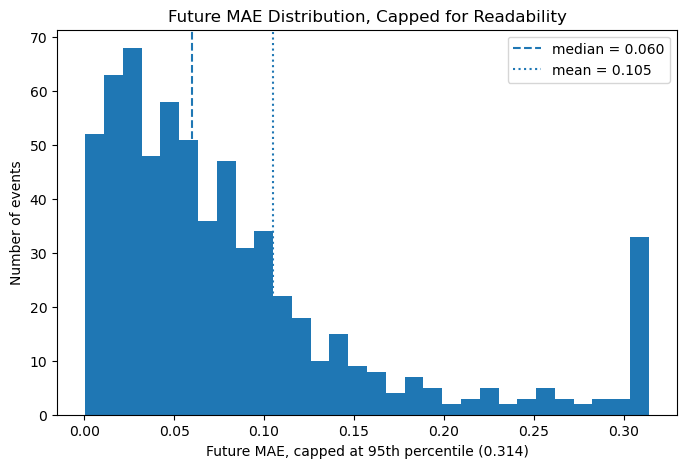

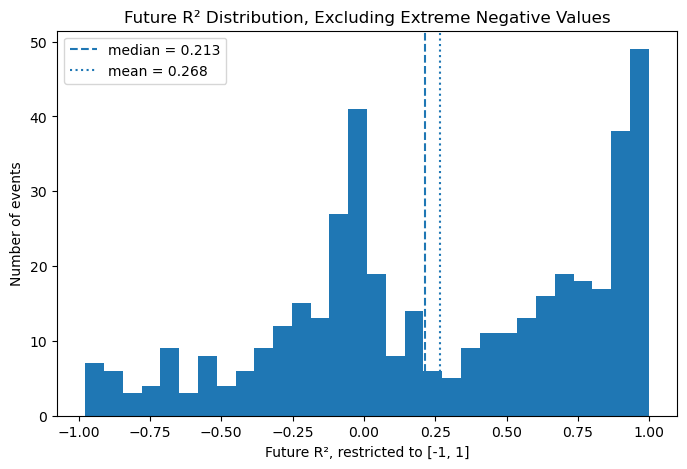

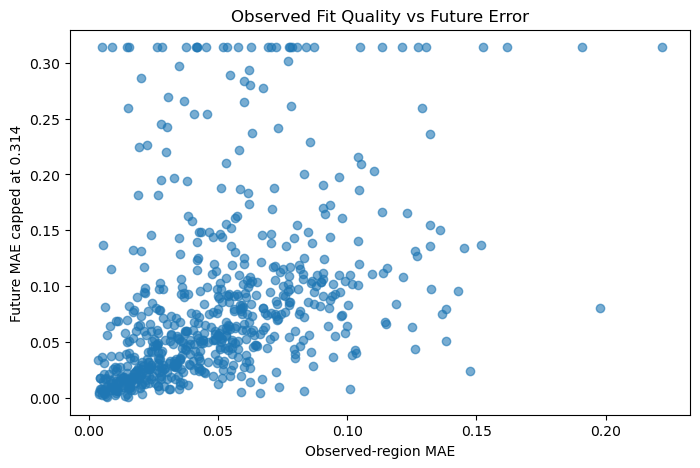

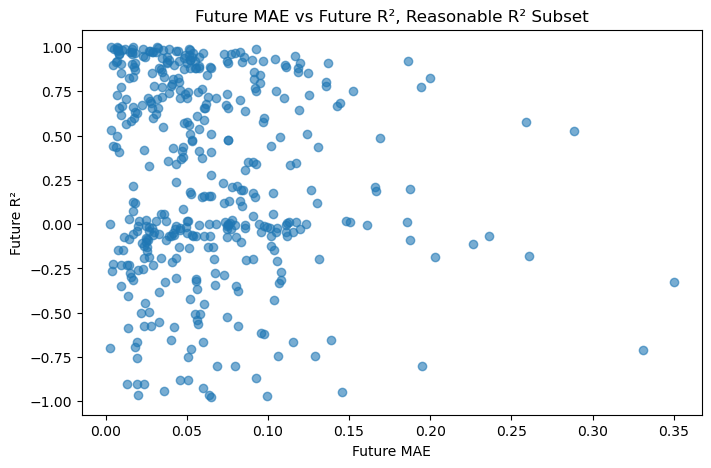


Saved cleaned CSV outputs:
clean_all_error_summary_seed67_all.csv
clean_r2_summary_seed67_all.csv
clean_r2_bucket_counts_seed67_all.csv
clean_percent_table_seed67_all.csv
clean_year_summary_seed67_all.csv
clean_best_r2_seed67_all.csv
clean_worst_reasonable_r2_seed67_all.csv
clean_best_mae_seed67_all.csv
clean_worst_mae_seed67_all.csv
clean_extreme_negative_r2_seed67_all.csv

DONE: Cleaned analysis complete.


In [4]:
# ============================
# INFORMATIVE CLEAN ANALYSIS CELL
# Run AFTER the all-curve seed-67 notebook
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Choose dataframe
# ----------------------------

if "results_df" not in globals():
    raise RuntimeError("results_df not found. Run the main notebook first.")

df = results_df.copy()

# Make numeric
for col in [
    "future_r2", "future_mae", "future_rmse",
    "obs_mae", "obs_rmse",
    "all_mae", "all_rmse",
    "final_loss", "fit_t0", "fit_tE", "fit_u0", "fit_I0", "fit_fbl"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Total evaluated events:", len(df))

# ----------------------------
# Create useful subsets
# ----------------------------

# 1. Events where future error exists
has_future_error = df[
    df["future_mae"].notna() &
    df["future_rmse"].notna()
].copy()

# 2. Events where R² is mathematically valid
r2_valid = has_future_error[
    df["future_r2"].notna() &
    np.isfinite(df["future_r2"])
].copy()

# 3. Practical R² subset: excludes insane negative R² values
# This is useful because extremely negative R² usually means the future segment has tiny variance.
r2_reasonable = r2_valid[
    (r2_valid["future_r2"] >= -1.0) &
    (r2_valid["future_r2"] <= 1.0)
].copy()

# 4. Stronger subset: non-negative R² only
r2_nonnegative = r2_valid[
    (r2_valid["future_r2"] >= 0.0) &
    (r2_valid["future_r2"] <= 1.0)
].copy()

print("\nSubset sizes:")
print("Events with future MAE/RMSE:", len(has_future_error))
print("Events with finite R²:", len(r2_valid))
print("Events with reasonable R² [-1, 1]:", len(r2_reasonable))
print("Events with nonnegative R² [0, 1]:", len(r2_nonnegative))
print("Events with NaN R²:", df["future_r2"].isna().sum())
print("Events with R² < -1:", (r2_valid["future_r2"] < -1).sum())


# ----------------------------
# Explain why NaN / extreme R² happens
# ----------------------------

print("\nR² interpretation note:")
print("NaN R² usually means the withheld future segment had too little variance or too few useful points.")
print("Extremely negative R² usually means the true future segment was nearly flat, so the R² denominator was tiny.")
print("For these cases, future MAE and future RMSE are more stable than R².")


# ----------------------------
# Main summary: all events, but focus on MAE/RMSE
# ----------------------------

stable_metrics = ["future_mae", "future_rmse", "obs_mae", "obs_rmse", "all_mae", "all_rmse"]

all_error_summary = has_future_error[stable_metrics].agg([
    "count", "mean", "median", "std", "min",
    lambda x: x.quantile(0.10),
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    lambda x: x.quantile(0.90),
    "max"
])

all_error_summary.index = [
    "count", "mean", "median", "std", "min",
    "10%", "25%", "75%", "90%", "max"
]

print("\n================================")
print("STABLE ERROR SUMMARY: ALL EVENTS WITH FUTURE DATA")
print("Use this for MAE/RMSE reporting")
print("================================")
display(all_error_summary)


# ----------------------------
# R² summary on finite and reasonable subsets
# ----------------------------

r2_summary = pd.DataFrame({
    "finite_r2_all": r2_valid["future_r2"].describe(),
    "reasonable_r2_-1_to_1": r2_reasonable["future_r2"].describe(),
    "nonnegative_r2_0_to_1": r2_nonnegative["future_r2"].describe(),
})

print("\n================================")
print("R² SUMMARY BY SUBSET")
print("================================")
display(r2_summary)


# ----------------------------
# R² buckets for finite R² and reasonable R²
# ----------------------------

def r2_bucket(r2):
    if pd.isna(r2) or not np.isfinite(r2):
        return "NaN / invalid"
    elif r2 >= 0.90:
        return "excellent: R² >= 0.90"
    elif r2 >= 0.75:
        return "strong: 0.75 <= R² < 0.90"
    elif r2 >= 0.50:
        return "decent: 0.50 <= R² < 0.75"
    elif r2 >= 0.00:
        return "weak: 0.00 <= R² < 0.50"
    elif r2 >= -1.00:
        return "poor: -1.00 <= R² < 0"
    else:
        return "extreme negative: R² < -1"

df["r2_bucket_clean"] = df["future_r2"].apply(r2_bucket)

bucket_order = [
    "excellent: R² >= 0.90",
    "strong: 0.75 <= R² < 0.90",
    "decent: 0.50 <= R² < 0.75",
    "weak: 0.00 <= R² < 0.50",
    "poor: -1.00 <= R² < 0",
    "extreme negative: R² < -1",
    "NaN / invalid"
]

r2_bucket_counts = (
    df["r2_bucket_clean"]
    .value_counts()
    .reindex(bucket_order)
    .fillna(0)
    .astype(int)
    .to_frame("count")
)

r2_bucket_counts["percent"] = 100 * r2_bucket_counts["count"] / len(df)

print("\n================================")
print("R² BUCKET COUNTS INCLUDING NaN / EXTREME CASES")
print("================================")
display(r2_bucket_counts)


# ----------------------------
# Useful percentages
# ----------------------------

n_total = len(df)
n_future = len(has_future_error)
n_reasonable = len(r2_reasonable)

percent_table = pd.DataFrame({
    "quantity": [
        "Total events",
        "Events with future MAE/RMSE",
        "Events with finite R²",
        "Events with reasonable R² [-1, 1]",
        "Events with R² >= 0.50",
        "Events with R² >= 0.75",
        "Events with R² >= 0.90",
        "Events with R² < 0",
        "Events with R² < -1",
        "Events with NaN R²",
    ],
    "count": [
        n_total,
        n_future,
        len(r2_valid),
        len(r2_reasonable),
        int((r2_valid["future_r2"] >= 0.50).sum()),
        int((r2_valid["future_r2"] >= 0.75).sum()),
        int((r2_valid["future_r2"] >= 0.90).sum()),
        int((r2_valid["future_r2"] < 0).sum()),
        int((r2_valid["future_r2"] < -1).sum()),
        int(df["future_r2"].isna().sum()),
    ],
})

percent_table["percent_of_total"] = 100 * percent_table["count"] / n_total

print("\n================================")
print("REPORT-FRIENDLY COUNT/PERCENT TABLE")
print("================================")
display(percent_table)


# ----------------------------
# Year summaries
# ----------------------------

year_summary_all = has_future_error.groupby("year").agg(
    n=("event_id", "count"),
    median_future_mae=("future_mae", "median"),
    mean_future_mae=("future_mae", "mean"),
    median_future_rmse=("future_rmse", "median"),
    mean_future_rmse=("future_rmse", "mean"),
    median_obs_mae=("obs_mae", "median"),
    mean_obs_mae=("obs_mae", "mean"),
).sort_index()

year_summary_r2_reasonable = r2_reasonable.groupby("year").agg(
    n_reasonable_r2=("event_id", "count"),
    median_future_r2=("future_r2", "median"),
    mean_future_r2=("future_r2", "mean"),
    min_future_r2=("future_r2", "min"),
    max_future_r2=("future_r2", "max"),
).sort_index()

year_summary_combined = year_summary_all.join(year_summary_r2_reasonable, how="left")

print("\n================================")
print("YEAR-BY-YEAR SUMMARY")
print("MAE/RMSE use all events with future data; R² uses reasonable subset [-1, 1]")
print("================================")
display(year_summary_combined)


# ----------------------------
# Best/worst tables that are actually informative
# ----------------------------

display_cols = [
    "event_id", "year",
    "future_r2", "future_mae", "future_rmse",
    "obs_mae", "obs_rmse",
    "all_mae", "all_rmse",
    "final_loss",
    "fit_t0", "fit_tE", "fit_u0", "fit_I0", "fit_fbl"
]
display_cols = [c for c in display_cols if c in df.columns]

print("\n================================")
print("BEST EVENTS BY REASONABLE FUTURE R²")
print("================================")
best_r2_clean = r2_reasonable.sort_values("future_r2", ascending=False).head(15)
display(best_r2_clean[display_cols])

print("\n================================")
print("WORST EVENTS BY REASONABLE FUTURE R²")
print("Excludes extreme negative R² below -1")
print("================================")
worst_r2_clean = r2_reasonable.sort_values("future_r2", ascending=True).head(15)
display(worst_r2_clean[display_cols])

print("\n================================")
print("BEST EVENTS BY FUTURE MAE")
print("This includes NaN R² cases because MAE is still valid")
print("================================")
best_mae_clean = has_future_error.sort_values("future_mae", ascending=True).head(15)
display(best_mae_clean[display_cols])

print("\n================================")
print("WORST EVENTS BY FUTURE MAE")
print("This is often more meaningful than worst R²")
print("================================")
worst_mae_clean = has_future_error.sort_values("future_mae", ascending=False).head(15)
display(worst_mae_clean[display_cols])

print("\n================================")
print("EXTREME NEGATIVE R² CASES")
print("Good to discuss as R² instability / low future-variance cases")
print("================================")
extreme_negative_r2 = r2_valid[r2_valid["future_r2"] < -1].sort_values("future_r2").head(20)
display(extreme_negative_r2[display_cols])


# ----------------------------
# More informative plots
# ----------------------------

# 1. Future MAE distribution, capped at 95th percentile
mae_cap = has_future_error["future_mae"].quantile(0.95)

plt.figure(figsize=(8, 5))
plt.hist(has_future_error["future_mae"].clip(upper=mae_cap), bins=30)
plt.axvline(has_future_error["future_mae"].median(), linestyle="--", label=f"median = {has_future_error['future_mae'].median():.3f}")
plt.axvline(has_future_error["future_mae"].mean(), linestyle=":", label=f"mean = {has_future_error['future_mae'].mean():.3f}")
plt.xlabel(f"Future MAE, capped at 95th percentile ({mae_cap:.3f})")
plt.ylabel("Number of events")
plt.title("Future MAE Distribution, Capped for Readability")
plt.legend()
plt.show()

# 2. Reasonable R² distribution only
plt.figure(figsize=(8, 5))
plt.hist(r2_reasonable["future_r2"], bins=30)
plt.axvline(r2_reasonable["future_r2"].median(), linestyle="--", label=f"median = {r2_reasonable['future_r2'].median():.3f}")
plt.axvline(r2_reasonable["future_r2"].mean(), linestyle=":", label=f"mean = {r2_reasonable['future_r2'].mean():.3f}")
plt.xlabel("Future R², restricted to [-1, 1]")
plt.ylabel("Number of events")
plt.title("Future R² Distribution, Excluding Extreme Negative Values")
plt.legend()
plt.show()

# 3. Observed MAE vs Future MAE, capped
plt.figure(figsize=(8, 5))
plot_df = has_future_error.copy()
plot_df["future_mae_capped"] = plot_df["future_mae"].clip(upper=mae_cap)
plt.scatter(plot_df["obs_mae"], plot_df["future_mae_capped"], alpha=0.6)
plt.xlabel("Observed-region MAE")
plt.ylabel(f"Future MAE capped at {mae_cap:.3f}")
plt.title("Observed Fit Quality vs Future Error")
plt.show()

# 4. Future MAE vs reasonable Future R²
plt.figure(figsize=(8, 5))
plt.scatter(r2_reasonable["future_mae"], r2_reasonable["future_r2"], alpha=0.6)
plt.xlabel("Future MAE")
plt.ylabel("Future R²")
plt.title("Future MAE vs Future R², Reasonable R² Subset")
plt.show()


# ----------------------------
# Save cleaned analysis
# ----------------------------

all_error_summary.to_csv("clean_all_error_summary_seed67_all.csv")
r2_summary.to_csv("clean_r2_summary_seed67_all.csv")
r2_bucket_counts.to_csv("clean_r2_bucket_counts_seed67_all.csv")
percent_table.to_csv("clean_percent_table_seed67_all.csv", index=False)
year_summary_combined.to_csv("clean_year_summary_seed67_all.csv")

best_r2_clean.to_csv("clean_best_r2_seed67_all.csv", index=False)
worst_r2_clean.to_csv("clean_worst_reasonable_r2_seed67_all.csv", index=False)
best_mae_clean.to_csv("clean_best_mae_seed67_all.csv", index=False)
worst_mae_clean.to_csv("clean_worst_mae_seed67_all.csv", index=False)
extreme_negative_r2.to_csv("clean_extreme_negative_r2_seed67_all.csv", index=False)

print("\nSaved cleaned CSV outputs:")
print("clean_all_error_summary_seed67_all.csv")
print("clean_r2_summary_seed67_all.csv")
print("clean_r2_bucket_counts_seed67_all.csv")
print("clean_percent_table_seed67_all.csv")
print("clean_year_summary_seed67_all.csv")
print("clean_best_r2_seed67_all.csv")
print("clean_worst_reasonable_r2_seed67_all.csv")
print("clean_best_mae_seed67_all.csv")
print("clean_worst_mae_seed67_all.csv")
print("clean_extreme_negative_r2_seed67_all.csv")

print("\nDONE: Cleaned analysis complete.")

Using BASE_DIR: /Users/andrewwang/Downloads/LIGHT/testing 3 cutoff
results_df columns:
['event_id', 'year', 'cutoff_file', 'full_file', 'params_file', 'final_loss', 'obs_mae', 'obs_rmse', 'all_mae', 'all_rmse', 'future_mae', 'future_rmse', 'future_r2', 'num_future_points', 'fit_t0', 'fit_tE', 'fit_u0', 'fit_I0', 'fit_fbl', 'true_StarNo', 'true_Tmax', 'true_tau', 'true_umin', 'true_Amax', 'true_Dmag', 'true_fbl', 'true_I_bl', 'true_I0', 'true_param_0', 'true_param_1', 'true_param_2', 'true_param_3', 'true_param_4', 'true_param_5', 'true_param_6', 'true_param_7', 'true_param_8', 'true_param_9', 'true_param_10', 'true_param_11', 'true_param_12', 'true_param_13', 'true_param_14', 'true_param_15', 'true_param_16']

Total events in results_df: 673
Events with usable true+fit parameters: 673

Parameter recovery metrics:


,param,r2,mae,rmse,median_abs_error
0,Tmax,0.997475,5.365727,66.922640,0.803000
1,tau,0.165569,13.540949,22.380769,7.697317
2,umin,-5.087759,0.241163,0.440106,0.093459
3,fbl,-1.313344,0.317730,0.394277,0.277663
4,I_bl,0.998474,0.024953,0.044752,0.011658


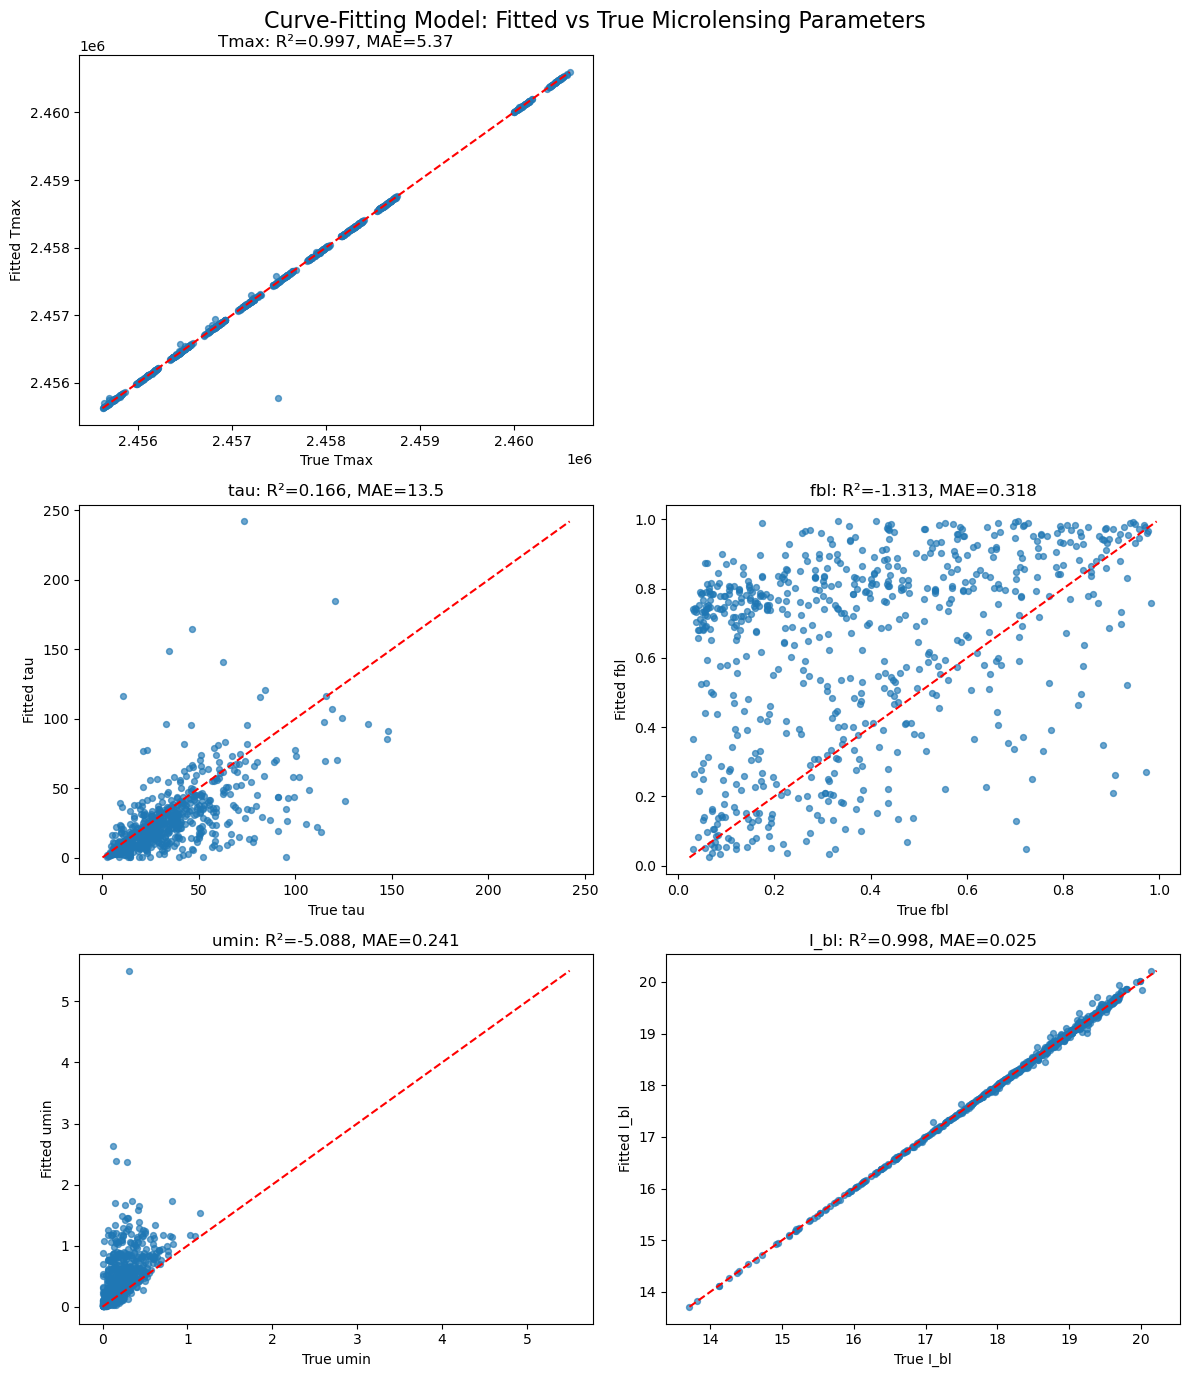

Saved: curvefit_params_pred_vs_true.png


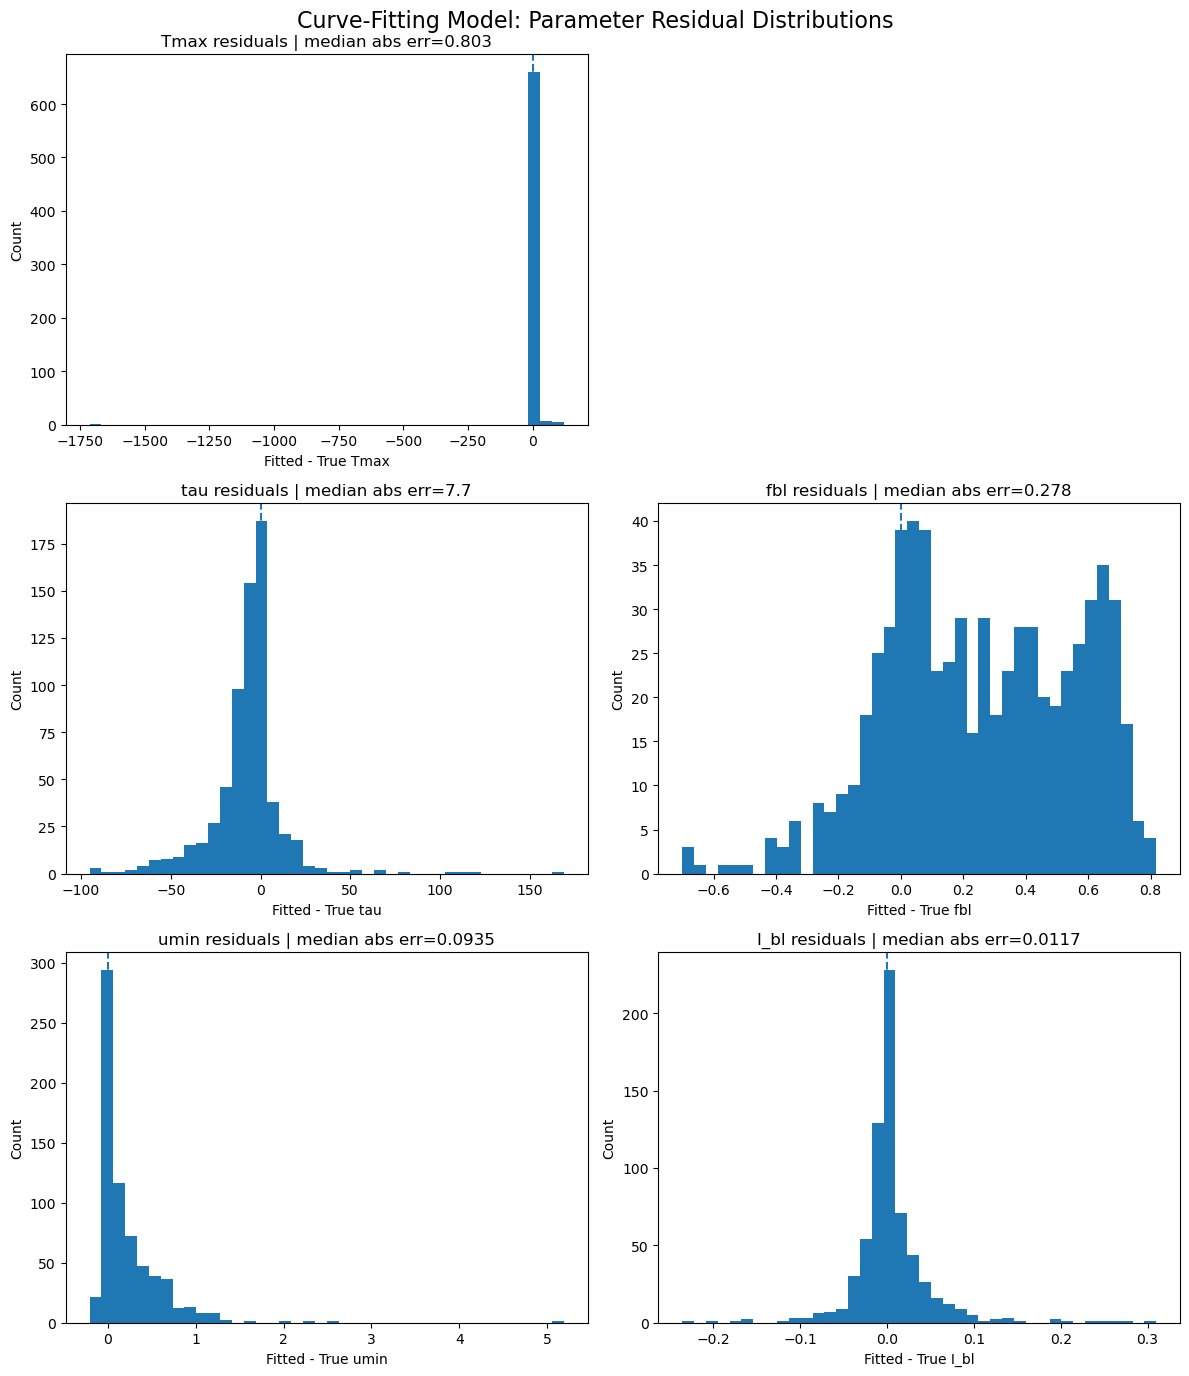

Saved: curvefit_param_residuals.png

Cleaned parameter plot subset: 618 / 673 events


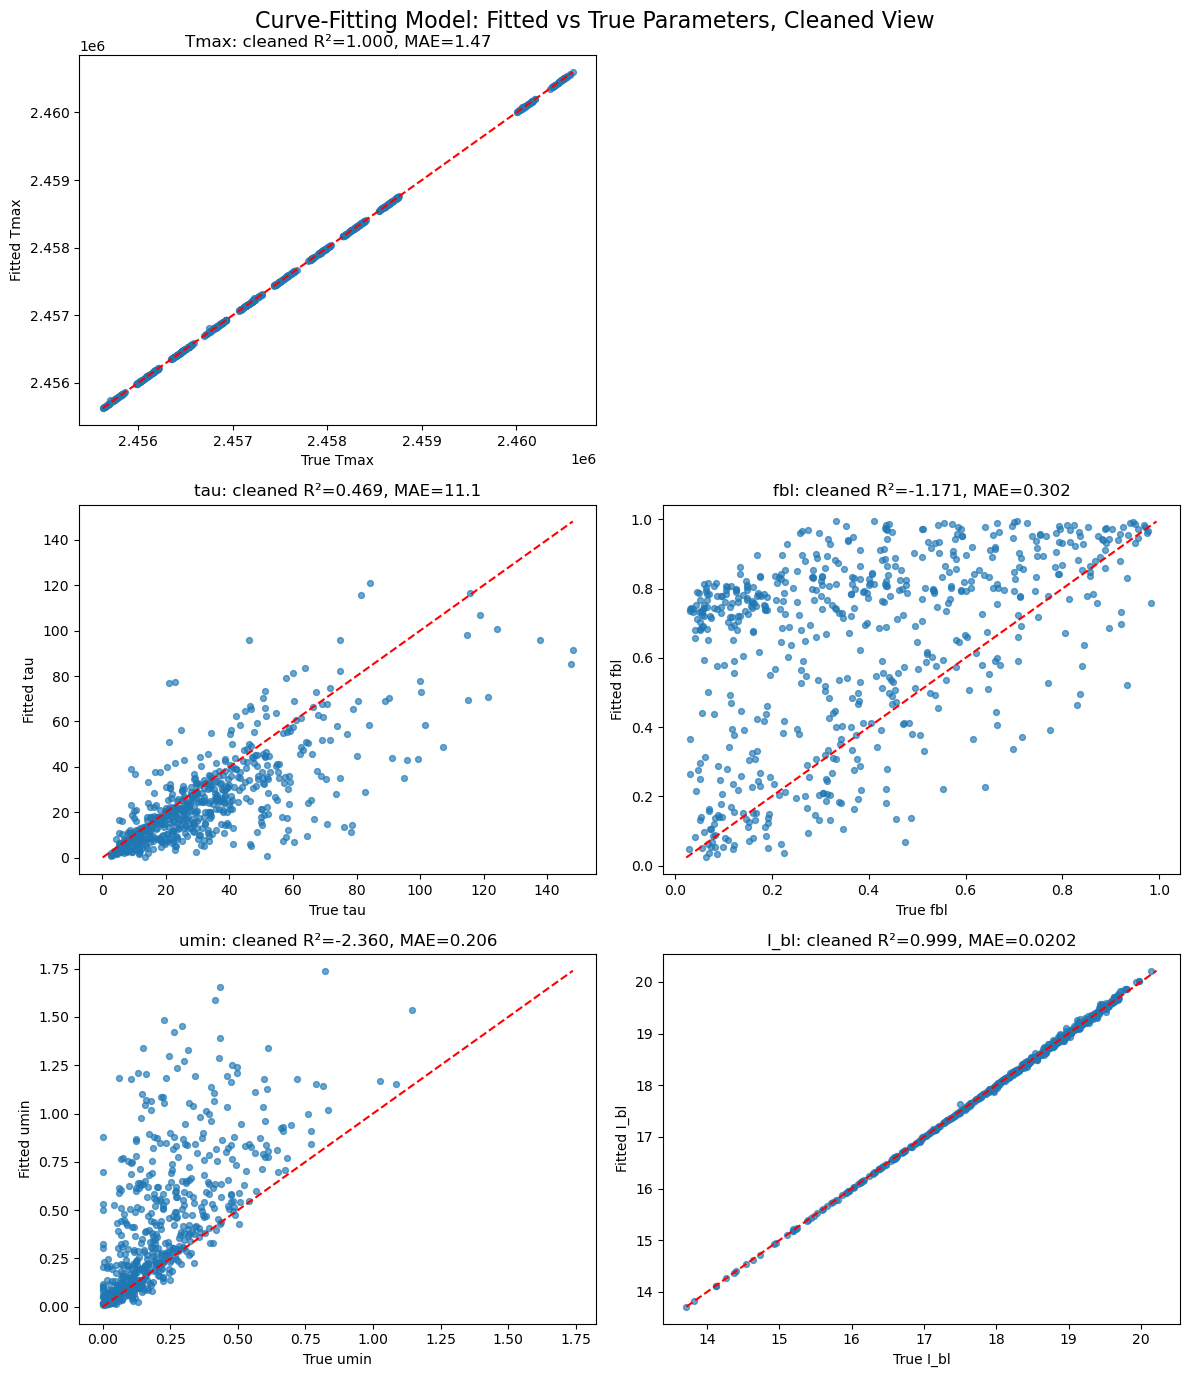

Saved: curvefit_params_pred_vs_true_cleaned.png
Saved: curvefit_parameter_recovery_full_table.csv

DONE.


In [6]:
# ============================
# FIXED PARAMETER RECOVERY PLOTS
# Fitted vs true params + residual histograms
# Run AFTER results_df exists
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if "results_df" not in globals():
    raise RuntimeError("results_df not found. Run the curve-fitting notebook first.")

df = results_df.copy()

if "BASE_DIR" in globals():
    BASE_DIR = Path(BASE_DIR).resolve()
else:
    BASE_DIR = Path.cwd().resolve()

print("Using BASE_DIR:", BASE_DIR)
print("results_df columns:")
print(df.columns.tolist())

# ----------------------------
# Parse true params from params files
# ----------------------------

def parse_named_params(path):
    wanted = ["Tmax", "tau", "umin", "fbl", "I_bl"]
    values = {k: np.nan for k in wanted}

    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2 and parts[0] in wanted:
                try:
                    values[parts[0]] = float(parts[1])
                except:
                    values[parts[0]] = np.nan

    return values


def get_params_path(row):
    # Prefer existing params_file column if available
    if "params_file" in row.index and pd.notna(row["params_file"]):
        p = Path(row["params_file"])
        if p.exists():
            return p

    event_id = str(row["event_id"])
    year = str(row["year"])
    return BASE_DIR / year / f"params_{event_id}.dat"


true_Tmax = []
true_tau = []
true_umin = []
true_fbl = []
true_I_bl = []
params_paths_used = []

for _, row in df.iterrows():
    ppath = get_params_path(row)
    params_paths_used.append(str(ppath))

    if not ppath.exists():
        true_Tmax.append(np.nan)
        true_tau.append(np.nan)
        true_umin.append(np.nan)
        true_fbl.append(np.nan)
        true_I_bl.append(np.nan)
        continue

    vals = parse_named_params(ppath)

    true_Tmax.append(vals["Tmax"])
    true_tau.append(vals["tau"])
    true_umin.append(vals["umin"])
    true_fbl.append(vals["fbl"])
    true_I_bl.append(vals["I_bl"])

df["true_Tmax"] = true_Tmax
df["true_tau"] = true_tau
df["true_umin"] = true_umin
df["true_fbl"] = true_fbl
df["true_I_bl"] = true_I_bl
df["params_path_used"] = params_paths_used

# ----------------------------
# Match true params to fitted params
# ----------------------------

param_map = {
    "Tmax": ("true_Tmax", "fit_t0"),
    "tau": ("true_tau", "fit_tE"),
    "umin": ("true_umin", "fit_u0"),
    "fbl": ("true_fbl", "fit_fbl"),
    "I_bl": ("true_I_bl", "fit_I0"),
}

needed_cols = []
for true_col, fit_col in param_map.values():
    needed_cols.extend([true_col, fit_col])

for col in needed_cols:
    if col not in df.columns:
        raise KeyError(f"Missing required column: {col}")
    df[col] = pd.to_numeric(df[col], errors="coerce")

param_df = df.dropna(subset=needed_cols).copy()

print(f"\nTotal events in results_df: {len(df)}")
print(f"Events with usable true+fit parameters: {len(param_df)}")

if len(param_df) == 0:
    print("\nExample params paths checked:")
    display(df[["event_id", "year", "params_path_used"]].head(10))
    raise RuntimeError("No usable parameter comparisons found. Check params file paths/format.")

# ----------------------------
# Metrics
# ----------------------------

def r2_score_np(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_res = np.sum((y_pred - y_true) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1 - ss_res / ss_tot


r2_per_param = {}
mae_per_param = {}
rmse_per_param = {}
median_abs_err_per_param = {}

for param_name, (true_col, fit_col) in param_map.items():
    y_true = param_df[true_col].values
    y_pred = param_df[fit_col].values
    residual = y_pred - y_true

    r2_per_param[param_name] = r2_score_np(y_true, y_pred)
    mae_per_param[param_name] = np.mean(np.abs(residual))
    rmse_per_param[param_name] = np.sqrt(np.mean(residual ** 2))
    median_abs_err_per_param[param_name] = np.median(np.abs(residual))

metric_table = pd.DataFrame({
    "param": list(param_map.keys()),
    "r2": [r2_per_param[p] for p in param_map.keys()],
    "mae": [mae_per_param[p] for p in param_map.keys()],
    "rmse": [rmse_per_param[p] for p in param_map.keys()],
    "median_abs_error": [median_abs_err_per_param[p] for p in param_map.keys()],
})

print("\nParameter recovery metrics:")
display(metric_table)

metric_table.to_csv("curvefit_parameter_recovery_metrics.csv", index=False)

# ----------------------------
# Fitted vs true plots
# ----------------------------

fig, axs = plt.subplots(3, 2, figsize=(12, 14))
axs = axs.flatten()

layout = {
    "Tmax": 0,
    "tau": 2,
    "umin": 4,
    "fbl": 3,
    "I_bl": 5,
}

axs[1].axis("off")

for param_name, ax_idx in layout.items():
    true_col, fit_col = param_map[param_name]
    ax = axs[ax_idx]

    y_true = param_df[true_col].values
    y_pred = param_df[fit_col].values

    ax.scatter(y_true, y_pred, s=18, alpha=0.65)

    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.5)

    ax.set_xlabel(f"True {param_name}")
    ax.set_ylabel(f"Fitted {param_name}")
    ax.set_title(
        f"{param_name}: R²={r2_per_param[param_name]:.3f}, "
        f"MAE={mae_per_param[param_name]:.3g}"
    )

plt.suptitle("Curve-Fitting Model: Fitted vs True Microlensing Parameters", fontsize=16)
plt.tight_layout()
plt.savefig("curvefit_params_pred_vs_true.png", dpi=200)
plt.show()

print("Saved: curvefit_params_pred_vs_true.png")

# ----------------------------
# Residual histograms
# ----------------------------

fig, axs = plt.subplots(3, 2, figsize=(12, 14))
axs = axs.flatten()

axs[1].axis("off")

for param_name, ax_idx in layout.items():
    true_col, fit_col = param_map[param_name]
    ax = axs[ax_idx]

    residuals = param_df[fit_col].values - param_df[true_col].values

    ax.hist(residuals, bins=40)
    ax.axvline(0, linestyle="--", linewidth=1.5)

    ax.set_xlabel(f"Fitted - True {param_name}")
    ax.set_ylabel("Count")
    ax.set_title(
        f"{param_name} residuals | "
        f"median abs err={median_abs_err_per_param[param_name]:.3g}"
    )

plt.suptitle("Curve-Fitting Model: Parameter Residual Distributions", fontsize=16)
plt.tight_layout()
plt.savefig("curvefit_param_residuals.png", dpi=200)
plt.show()

print("Saved: curvefit_param_residuals.png")

# ----------------------------
# Cleaned visualization: remove extreme residual outliers
# ----------------------------

clean_param_df = param_df.copy()

for param_name, (true_col, fit_col) in param_map.items():
    resid_col = f"resid_{param_name}"
    clean_param_df[resid_col] = clean_param_df[fit_col] - clean_param_df[true_col]

mask = np.ones(len(clean_param_df), dtype=bool)

for param_name in param_map.keys():
    resid_col = f"resid_{param_name}"
    low = clean_param_df[resid_col].quantile(0.01)
    high = clean_param_df[resid_col].quantile(0.99)
    mask &= clean_param_df[resid_col].between(low, high)

clean_param_df = clean_param_df[mask].copy()

print(f"\nCleaned parameter plot subset: {len(clean_param_df)} / {len(param_df)} events")

fig, axs = plt.subplots(3, 2, figsize=(12, 14))
axs = axs.flatten()

axs[1].axis("off")

for param_name, ax_idx in layout.items():
    true_col, fit_col = param_map[param_name]
    ax = axs[ax_idx]

    y_true = clean_param_df[true_col].values
    y_pred = clean_param_df[fit_col].values

    clean_r2 = r2_score_np(y_true, y_pred)
    clean_mae = np.mean(np.abs(y_pred - y_true))

    ax.scatter(y_true, y_pred, s=18, alpha=0.65)

    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.5)

    ax.set_xlabel(f"True {param_name}")
    ax.set_ylabel(f"Fitted {param_name}")
    ax.set_title(f"{param_name}: cleaned R²={clean_r2:.3f}, MAE={clean_mae:.3g}")

plt.suptitle("Curve-Fitting Model: Fitted vs True Parameters, Cleaned View", fontsize=16)
plt.tight_layout()
plt.savefig("curvefit_params_pred_vs_true_cleaned.png", dpi=200)
plt.show()

print("Saved: curvefit_params_pred_vs_true_cleaned.png")

# ----------------------------
# Save full table
# ----------------------------

param_comparison_cols = [
    "event_id", "year",
    "true_Tmax", "fit_t0",
    "true_tau", "fit_tE",
    "true_umin", "fit_u0",
    "true_fbl", "fit_fbl",
    "true_I_bl", "fit_I0",
    "future_mae", "future_rmse", "future_r2",
    "obs_mae", "obs_rmse",
    "params_path_used",
]

param_comparison_cols = [c for c in param_comparison_cols if c in df.columns]

df[param_comparison_cols].to_csv("curvefit_parameter_recovery_full_table.csv", index=False)

print("Saved: curvefit_parameter_recovery_full_table.csv")
print("\nDONE.")